# Medication Recommender

In [1]:
from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/CMPE 256 - Project')
os.chdir(PROJECT_DIR)
print('current directory:', Path.cwd())

Mounted at /content/drive
current directory: /content/drive/.shortcut-targets-by-id/1aqZsPEz2Oa8kz7RWblFRGdYj1_wWzD8l/CMPE 256 - Project


## Prepare

In [ ]:
# this file is to prepare the dataset
# take raw tables and turn them into a format for modeling
# we will end up with 2 tables
# one is (patient, admission) -> patient features, admission features, history
# the other one is (patient, admission, drug) -> label

from pathlib import Path
import json

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, save_npz

DATA_DIR = Path("data/baseline_tables")
PROCESSED_DIR = Path("data/processed")
REFERENCE_DIR = Path("data/reference")

RANDOM_STATE = 42

# negative sampling
# model needs both positive and negative examples to learn what is good/bad
NEGATIVES_PER_POSITIVE = 10

# lab sources tables
LAB_SOURCES = [
    "chemistry",
    "complete_blood_count",
    "coagulation",
    "enzyme",
    "blood_differential",
    "cardiac_marker",
    "bg",
]


In [ ]:
# build diagnoses matrix
# use multi-hot encoding matrix
# returns:
# a sparse matrix (num_admissions, num_icd_codes)
# and a list of ICD codes, mapping column index to code
def build_current_dx_matrix(snapshot, diagnoses):
    # map each hadm_id to row number
    snap_hadms = snapshot["hadm_id"].tolist()
    hadm_to_row = {h: i for i, h in enumerate(snap_hadms)}

    dx = diagnoses.dropna(subset=["hadm_id", "icd_code"]).copy()
    dx["icd_code"] = dx["icd_code"].astype(str).str.strip()
    dx = dx[dx["icd_code"] != ""]
    dx = dx[dx["hadm_id"].isin(hadm_to_row)]
    dx = dx[["hadm_id", "icd_code"]].drop_duplicates()

    dx_codes = sorted(dx["icd_code"].unique())
    # map icd code to column number
    code_to_col = {code: i for i, code in enumerate(dx_codes)}

    # now build sparse matrix (multi-hot)
    rows = dx["hadm_id"].map(hadm_to_row).values
    cols = dx["icd_code"].map(code_to_col).values
    data = np.ones(len(dx), dtype=np.int8)
    matrix = csr_matrix((data, (rows, cols)), shape=(snapshot.shape[0], len(dx_codes)))
    return matrix, dx_codes


In [ ]:
# HISTORY (patient's past admissions)
# includes prior diagnoses, medications, procedures, number of admissions, days since last admission
# basically collapsing user history into a fixed size feature vector
def compute_history(snapshot, diagnoses, interactions, procedures, dx_codes, medications, proc_codes):
    dx_to_col = {c: i for i, c in enumerate(dx_codes)}
    med_to_col = {m: i for i, m in enumerate(medications)}
    proc_to_col = {c: i for i, c in enumerate(proc_codes)}

    n_rows = len(snapshot)
    num_prior_admissions = np.zeros(n_rows, dtype=int)
    days_since_last_admission = np.full(n_rows, np.nan)

    # per admission diagnosis/medication/procedure sets
    dx_clean = diagnoses.dropna(subset=["hadm_id", "icd_code"]).copy()
    dx_clean["icd_code"] = dx_clean["icd_code"].astype(str).str.strip()
    dx_clean = dx_clean[dx_clean["icd_code"] != ""]

    proc_clean = procedures.dropna(subset=["hadm_id", "icd_code"]).copy()
    proc_clean["icd_code"] = proc_clean["icd_code"].astype(str).str.strip()
    proc_clean = proc_clean[proc_clean["icd_code"] != ""]

    current_dx_by_hadm = {}
    for hadm_id, grp in dx_clean.groupby("hadm_id"):
        current_dx_by_hadm[hadm_id] = set(grp["icd_code"])

    current_meds_by_hadm = {}
    for hadm_id, grp in interactions.groupby("hadm_id"):
        current_meds_by_hadm[hadm_id] = set(grp["medication"])

    current_proc_by_hadm = {}
    for hadm_id, grp in proc_clean.groupby("hadm_id"):
        current_proc_by_hadm[hadm_id] = set(grp["icd_code"])

    prior_dx_rows, prior_dx_cols = [], []
    prior_med_rows, prior_med_cols = [], []
    prior_proc_rows, prior_proc_cols = [], []

    # go through each patient's admissions in chronological order
    # and build their history
    for _, group in snapshot.groupby("subject_id", sort=False):
        seen_dx = set()
        seen_meds = set()
        seen_procs = set()
        last_admit_time = None
        prior_count = 0

        for row in group.itertuples():
            i = row.Index
            num_prior_admissions[i] = prior_count

            # days_since_last_admission
            if last_admit_time is not None:
                gap = (row.admittime - last_admit_time).days
                days_since_last_admission[i] = gap

            for code in seen_dx:
                if code in dx_to_col:
                    prior_dx_rows.append(i)
                    prior_dx_cols.append(dx_to_col[code])
            for med in seen_meds:
                if med in med_to_col:
                    prior_med_rows.append(i)
                    prior_med_cols.append(med_to_col[med])
            for code in seen_procs:
                if code in proc_to_col:
                    prior_proc_rows.append(i)
                    prior_proc_cols.append(proc_to_col[code])

            if row.hadm_id in current_dx_by_hadm:
                seen_dx.update(current_dx_by_hadm[row.hadm_id])
            if row.hadm_id in current_meds_by_hadm:
                seen_meds.update(current_meds_by_hadm[row.hadm_id])
            if row.hadm_id in current_proc_by_hadm:
                seen_procs.update(current_proc_by_hadm[row.hadm_id])
            last_admit_time = row.admittime
            prior_count += 1

    dx_data = np.ones(len(prior_dx_rows), dtype=np.int8)
    prior_dx_matrix = csr_matrix(
        (dx_data, (prior_dx_rows, prior_dx_cols)),
        shape=(n_rows, len(dx_codes)),
    )

    med_data = np.ones(len(prior_med_rows), dtype=np.int8)
    prior_med_matrix = csr_matrix(
        (med_data, (prior_med_rows, prior_med_cols)),
        shape=(n_rows, len(medications)),
    )

    proc_data = np.ones(len(prior_proc_rows), dtype=np.int8)
    prior_proc_matrix = csr_matrix(
        (proc_data, (prior_proc_rows, prior_proc_cols)),
        shape=(n_rows, len(proc_codes)),
    )

    history = pd.DataFrame(
        {
            "num_prior_admissions": num_prior_admissions,
            "days_since_last_admission": days_since_last_admission,
        },
        index=snapshot.index,
    )
    return history, prior_dx_matrix, prior_med_matrix, prior_proc_matrix


In [ ]:
# labs - just first value per admission for each test
def build_current_labs(snapshot, source):
    df = pd.read_csv(DATA_DIR / f"{source}.csv", low_memory=False)
    # drop labs not tied to admissions
    df = df.dropna(subset=["hadm_id"]).copy()
    df["hadm_id"] = df["hadm_id"].astype(int)
    df = df[df["hadm_id"].isin(set(snapshot["hadm_id"]))]
    df["charttime"] = pd.to_datetime(df["charttime"], errors="coerce")
    df = df.sort_values(["hadm_id", "charttime"])

    lab_cols = [c for c in df.columns if c not in ("hadm_id", "charttime")]

    first = df.groupby("hadm_id")[lab_cols].first()
    aligned = first.reindex(snapshot["hadm_id"])

    values = aligned.to_numpy(dtype=np.float32)
    flags = (~aligned.isna()).to_numpy(dtype=np.float32)
    return values, flags, lab_cols


# labs history
def compute_prior_labs(snapshot, current_values, current_flags):
    n_rows, n_cols = current_values.shape
    prior_values = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
    prior_flags = np.zeros((n_rows, n_cols), dtype=np.float32)

    for _, group in snapshot.groupby("subject_id", sort=False):
        last_vals = np.full(n_cols, np.nan, dtype=np.float32)
        last_flags = np.zeros(n_cols, dtype=np.float32)
        for row in group.itertuples():
            i = row.Index
            prior_values[i] = last_vals
            prior_flags[i] = last_flags

            measured = current_flags[i] > 0
            last_vals[measured] = current_values[i][measured]
            last_flags[measured] = 1.0

    return prior_values, prior_flags


# build the label table for admission drug pairs (final interaction table)
# build negative samples for training
def make_label_table(snapshot, interactions):
    rng = np.random.default_rng(RANDOM_STATE)
    all_drugs = sorted(interactions["medication"].unique())

    positive_by_hadm = {}
    for hadm_id, grp in interactions.groupby("hadm_id"):
        positive_by_hadm[hadm_id] = set(grp["medication"])

    rows = []
    for hadm_id in snapshot["hadm_id"]:
        positive_drugs = positive_by_hadm[hadm_id]

        for drug in sorted(positive_drugs):
            rows.append({"hadm_id": hadm_id, "candidate_drug": drug, "label": 1})

        # sample negatives from drugs not given in this admission
        non_positive_drugs = [d for d in all_drugs if d not in positive_drugs]

        n_neg = min(NEGATIVES_PER_POSITIVE * len(positive_drugs), len(non_positive_drugs))
        negative_drugs = rng.choice(non_positive_drugs, size=n_neg, replace=False)

        for drug in sorted(negative_drugs):
            rows.append({"hadm_id": hadm_id, "candidate_drug": drug, "label": 0})

    return pd.DataFrame(rows)


In [ ]:
# === put everything together ===

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("loading raw tables...")
admissions = pd.read_csv(DATA_DIR / "admissions.csv", low_memory=False)
patients = pd.read_csv(DATA_DIR / "patients.csv", low_memory=False)
diagnoses = pd.read_csv(DATA_DIR / "diagnoses_icd.csv", low_memory=False)
emar = pd.read_csv(DATA_DIR / "emar.csv", low_memory=False)
procedures = pd.read_csv(DATA_DIR / "procedures_icd.csv", low_memory=False)
print("admissions:", len(admissions), "patients:", len(patients))
print("diagnoses:", len(diagnoses), "emar:", len(emar), "procedures:", len(procedures))


# creates (hadm_id, medication) foundation
# no matching hadm_id - means not tied to an admission
interactions = emar.dropna(subset=["hadm_id"]).copy()
interactions["hadm_id"] = interactions["hadm_id"].astype(int)

meds = interactions["medication"].fillna("")
meds = meds.astype(str).str.strip()
interactions["medication"] = meds
interactions = interactions[interactions["medication"] != ""]

# for each admission, what drugs were administered (no dups)
interactions = interactions[["hadm_id", "medication"]].drop_duplicates()
interactions = interactions.reset_index(drop=True)

# normalize medication names
drug_to_ingredient = pd.read_csv(REFERENCE_DIR / "drug_to_ingredient.csv")
d2i = dict(zip(drug_to_ingredient["drug"], drug_to_ingredient["ingredient_name"]))
interactions["medication"] = interactions["medication"].map(d2i).fillna(interactions["medication"])
interactions = interactions.drop_duplicates().reset_index(drop=True)

print("interactions:", len(interactions))
print("Top 20 medications after normalization:")
print(interactions["medication"].value_counts().head(20))


# start by joining patients/admissions, building basic blocks
# one row per admission
# patient is an easy merge into admissions
snapshot = admissions.merge(patients, on="subject_id", how="left")
snapshot["admittime"] = pd.to_datetime(snapshot["admittime"])

# get age, we need to calculate this because of how MIMIC shuffles data
snapshot["age_at_admission"] = (
    snapshot["anchor_age"] + snapshot["admittime"].dt.year - snapshot["anchor_year"]
)
snapshot = snapshot.drop(columns=["anchor_age", "anchor_year"])

# remove admissions that don't have any medication records (useless to us)
valid_hadms = set(interactions["hadm_id"])
snapshot = snapshot[snapshot["hadm_id"].isin(valid_hadms)]

# sort so we can create user history later.
snapshot = snapshot.sort_values(["subject_id", "admittime", "hadm_id"])
snapshot = snapshot.reset_index(drop=True)
print("snapshot:", snapshot.shape)

# normalized diagnosis/prcedures
dx_map = pd.read_csv(REFERENCE_DIR / "dx_ccsr_map.csv", dtype=str)
proc_map = pd.read_csv(REFERENCE_DIR / "proc_ccs_map.csv", dtype=str)
diagnoses_norm = (
    diagnoses.assign(icd_version=diagnoses["icd_version"].astype(str))
    .merge(dx_map, on=["icd_code", "icd_version"], how="inner")
    [["hadm_id", "ccsr_category"]].rename(columns={"ccsr_category": "icd_code"})
)
procedures_norm = (
    procedures.assign(icd_version=procedures["icd_version"].astype(str))
    .merge(proc_map, on=["icd_code", "icd_version"], how="inner")
    [["hadm_id", "ccs_category"]].rename(columns={"ccs_category": "icd_code"})
)
print(f"dx: {diagnoses_norm['icd_code'].nunique()} CCSR categories, proc: {procedures_norm['icd_code'].nunique()} CCS categories")

print("building current dx matrix...")
current_dx_matrix, dx_codes = build_current_dx_matrix(snapshot, diagnoses_norm)
medications = sorted(interactions["medication"].unique())
print("dx codes:", len(dx_codes), "medications:", len(medications))

print("building current proc matrix...")
current_proc_matrix, proc_codes = build_current_dx_matrix(snapshot, procedures_norm)
print("proc codes:", len(proc_codes))

print("computing history features...")
history_features, prior_dx_matrix, prior_med_matrix, prior_proc_matrix = compute_history(
    snapshot, diagnoses_norm, interactions, procedures_norm, dx_codes, medications, proc_codes
)

patient_admission_snapshot = pd.concat([snapshot, history_features], axis=1)

# charlson, 1 to 1 rows with admissions
print("merging charlson...")
charlson = pd.read_csv(DATA_DIR / "charlson.csv", low_memory=False)
charlson = charlson.drop_duplicates("hadm_id")
patient_admission_snapshot = patient_admission_snapshot.merge(
    charlson, on="hadm_id", how="left"
)

# services: last current service per admission
print("merging services...")
services = pd.read_csv(DATA_DIR / "services.csv", low_memory=False)
services = services.sort_values("transfertime")
services = services.drop_duplicates("hadm_id", keep="last")
services = services[["hadm_id", "curr_service"]]
patient_admission_snapshot = patient_admission_snapshot.merge(
    services, on="hadm_id", how="left"
)

# labs
print("building lab matrices...")
lab_cols_by_source = {}
for source in LAB_SOURCES:
    print(f"  {source}...")
    current_v, current_f, lab_cols = build_current_labs(snapshot, source)
    prior_v, prior_f = compute_prior_labs(snapshot, current_v, current_f)
    np.savez_compressed(PROCESSED_DIR / f"current_{source}_labs.npz", values=current_v, flags=current_f)
    np.savez_compressed(PROCESSED_DIR / f"prior_{source}_labs.npz", values=prior_v, flags=prior_f)
    lab_cols_by_source[source] = lab_cols

print("making label table...")
admission_drug_labels = make_label_table(snapshot, interactions)
print("label rows:", len(admission_drug_labels))
admission_drug_labels.to_csv(PROCESSED_DIR / "admission_drug_labels.csv", index=False)


# save everything

patient_admission_snapshot.to_csv(PROCESSED_DIR / "patient_admission_snapshot.csv", index=False)
save_npz(PROCESSED_DIR / "current_dx_matrix.npz", current_dx_matrix)
save_npz(PROCESSED_DIR / "prior_dx_matrix.npz", prior_dx_matrix)
save_npz(PROCESSED_DIR / "prior_med_matrix.npz", prior_med_matrix)
save_npz(PROCESSED_DIR / "current_proc_matrix.npz", current_proc_matrix)
save_npz(PROCESSED_DIR / "prior_proc_matrix.npz", prior_proc_matrix)

charlson_cols = [c for c in charlson.columns if c != "hadm_id"]
metadata = {
    "dx_codes": dx_codes,
    "medications": medications,
    "proc_codes": proc_codes,
    "lab_sources": lab_cols_by_source,
    "charlson_cols": charlson_cols,
    "negatives_per_positive": NEGATIVES_PER_POSITIVE,
    "random_state": RANDOM_STATE,
}
with open(PROCESSED_DIR / "feature_metadata.json", "w") as fp:
    json.dump(metadata, fp, indent=2)

print("done")


loading raw tables...
admissions: 546028 patients: 364627
diagnoses: 6364488 emar: 28419780 procedures: 859655
interactions: 4053455
Top 20 medications after normalization:
medication
acetaminophen               192765
heparin                     143706
docusate                    108539
oxycodone                    92038
aspirin                      90438
sennosides, USP              85439
ondansetron                  80641
potassium chloride           76638
hydromorphone                71656
metoprolol                   71532
magnesium sulfate            70395
insulin lispro               69311
atorvastatin                 63949
furosemide                   58417
lorazepam                    57907
omeprazole                   54393
pantoprazole                 52196
polyethylene glycol 3350     50203
vancomycin                   49250
gabapentin                   45393
Name: count, dtype: int64
snapshot: (289685, 11)
dx: 539 CCSR categories, proc: 231 CCS categories
building current 

## EDA

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data/baseline_tables")
PROCESSED_DIR = Path("data/processed")

snapshot = pd.read_csv(PROCESSED_DIR / "patient_admission_snapshot.csv", low_memory=False)
labels = pd.read_csv(PROCESSED_DIR / "admission_drug_labels.csv", low_memory=False)
admissions = pd.read_csv(DATA_DIR / "admissions.csv", low_memory=False)
admissions_per_patient = admissions.groupby("subject_id").size()

def show():
    plt.tight_layout()
    plt.show()
    plt.close()

positives = labels[labels["label"] == 1]


positives per admission:
median: 12
p75: 19
p95: 32


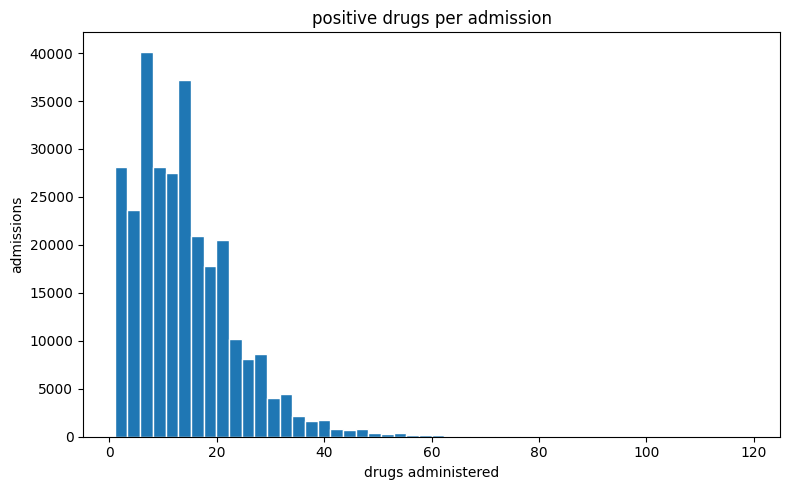

In [ ]:
# part 1: justify ranking
print("\npositives per admission:")

# drugs per adminission
# multiple drugs per admission means classification
# is not appropriate, we need a ranking approach
pos_per_adm = positives.groupby("hadm_id").size()
print(f"median: {pos_per_adm.median():.0f}")
print(f"p75: {pos_per_adm.quantile(0.75):.0f}")
print(f"p95: {pos_per_adm.quantile(0.95):.0f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pos_per_adm, bins=50, edgecolor="white")
ax.set_title("positive drugs per admission")
ax.set_xlabel("drugs administered")
ax.set_ylabel("admissions")
show()


drug popularity:
top 10 drugs: 25.0% of positives
drugs seen <10 times: 1,216
median admissions per drug: 6


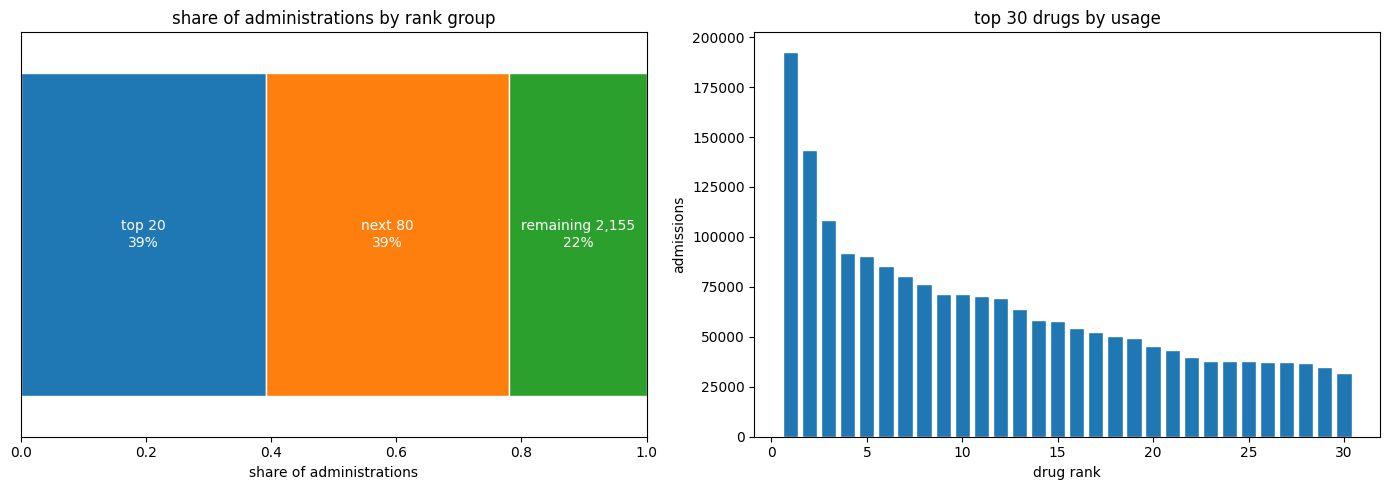

In [ ]:
# part 2: popularity bias
print("\ndrug popularity:")

# are just a few drugs accounting for most administrations?
# because of this, we expect popularity baseline to do well
drug_counts = positives["candidate_drug"].value_counts()
cumulative_share = drug_counts.cumsum() / drug_counts.sum()
top_10_share = cumulative_share.iloc[9]
rare_lt_10 = (drug_counts < 10).sum()

print(f"top 10 drugs: {top_10_share:.1%} of positives")
print(f"drugs seen <10 times: {rare_lt_10:,}")
print(f"median admissions per drug: {drug_counts.median():.0f}")

# "top 20% of drugs account for 40% of administrations"
n_drugs_total = len(drug_counts)
top20_share = drug_counts.iloc[:20].sum() / drug_counts.sum()
next80_share = drug_counts.iloc[20:100].sum() / drug_counts.sum()
rest_share = drug_counts.iloc[100:].sum() / drug_counts.sum()
n_rest = max(n_drugs_total - 100, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segments = [
    ("top 20", top20_share),
    ("next 80", next80_share),
    (f"remaining {n_rest:,}", rest_share),
]
left = 0
for label, share in segments:
    axes[0].barh(0, share, left=left, edgecolor="white")
    axes[0].text(left + share / 2, 0, f"{label}\n{share:.0%}", ha="center", va="center", color="white")
    left += share
axes[0].set_xlim(0, 1)
axes[0].set_ylim(-0.5, 0.5)
axes[0].set_yticks([])
axes[0].set_xlabel("share of administrations")
axes[0].set_title("share of administrations by rank group")

top_n = 30
top_drugs = drug_counts.head(top_n)
axes[1].bar(range(1, top_n + 1), top_drugs.values, edgecolor="white")
axes[1].set_title("top 30 drugs by usage")
axes[1].set_xlabel("drug rank")
axes[1].set_ylabel("admissions")
show()


cold start:
cold-start patients: 123,289 (55.2%)
warm-start patients: 100,163 (44.8%)
p95 prior admissions: 10


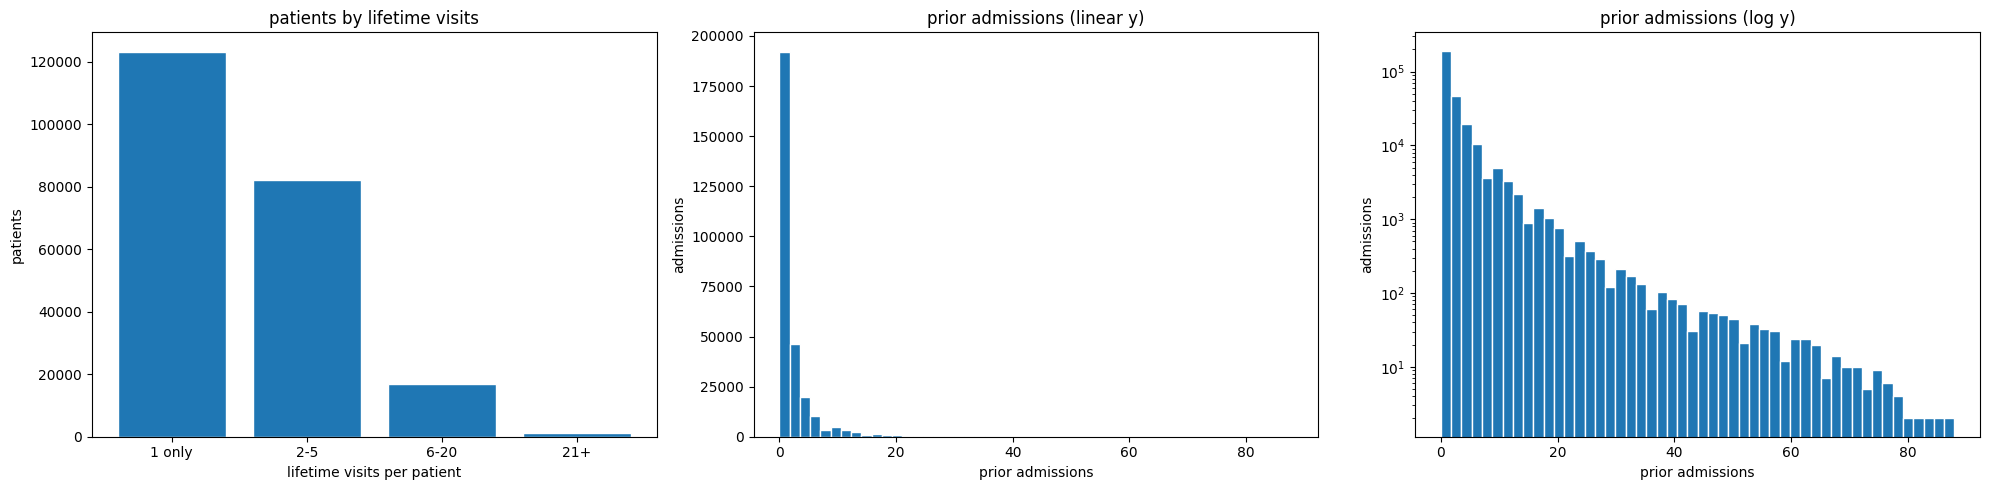

In [ ]:
# slide 3: cold start limits pure CF
print("\ncold start:")

# how many cold start users
n_patients = len(admissions_per_patient)
cold_start = (admissions_per_patient == 1).sum()
warm_start = (admissions_per_patient > 1).sum()
print(f"cold-start patients: {cold_start:,} ({cold_start / n_patients:.1%})")
print(f"warm-start patients: {warm_start:,} ({warm_start / n_patients:.1%})")
print(f"p95 prior admissions: {snapshot['num_prior_admissions'].quantile(0.95):.0f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# bucketed version of 2nd plot
bucket_labels = ["1 only", "2-5", "6-20", "21+"]
visit_buckets = pd.cut(
    admissions_per_patient,
    bins=[0, 1, 5, 20, np.inf],
    labels=bucket_labels,
    right=True,
    include_lowest=True,
)
patient_bucket_counts = visit_buckets.value_counts().reindex(bucket_labels)
axes[0].bar(patient_bucket_counts.index, patient_bucket_counts.values, edgecolor="white")
axes[0].set_title("patients by lifetime visits")
axes[0].set_xlabel("lifetime visits per patient")
axes[0].set_ylabel("patients")

# linear
axes[1].hist(snapshot["num_prior_admissions"], bins=50, edgecolor="white")
axes[1].set_title("prior admissions (linear y)")
axes[1].set_xlabel("prior admissions")
axes[1].set_ylabel("admissions")

# log
axes[2].hist(snapshot["num_prior_admissions"], bins=50, edgecolor="white")
axes[2].set_title("prior admissions (log y)")
axes[2].set_xlabel("prior admissions")
axes[2].set_ylabel("admissions")
axes[2].set_yscale("log")

show()


prior-drug overlap (warm only):
median overlap with prior drugs: 66.7%
warm visits with any overlap: 148,126 (97.1%)


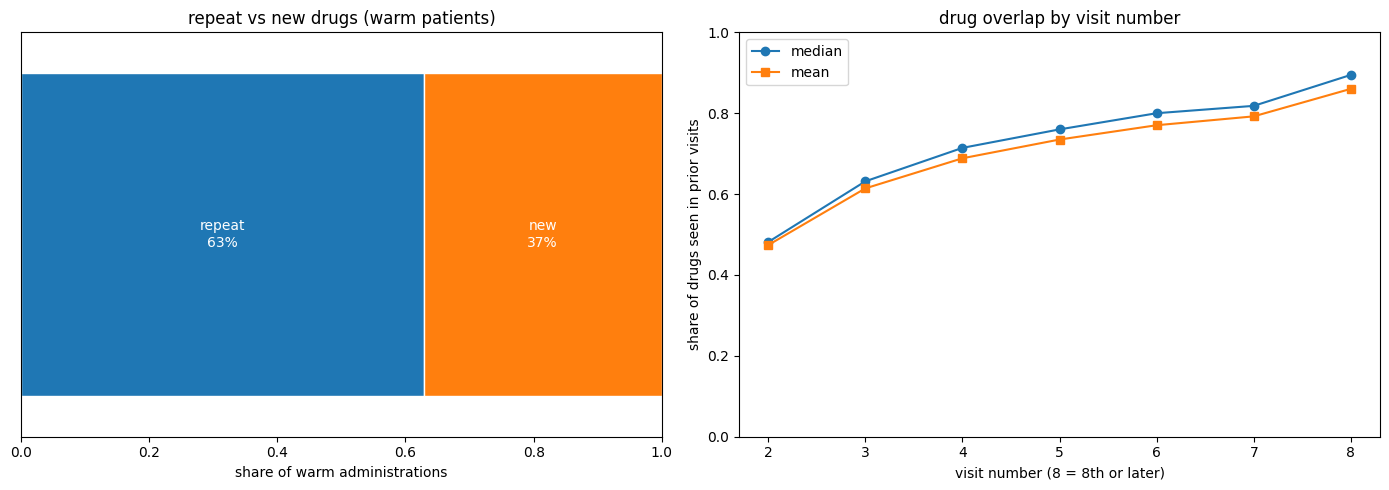

In [ ]:
# slide 4: history
print("\nprior-drug overlap (warm only):")

# do past drugs repeat
drug_sets = positives.groupby("hadm_id")["candidate_drug"].apply(set)
visit_info = snapshot[["hadm_id", "subject_id", "admittime"]].copy()
visit_info["admittime"] = pd.to_datetime(visit_info["admittime"])
visit_info = visit_info.sort_values(["subject_id", "admittime", "hadm_id"])
visit_info["drug_set"] = visit_info["hadm_id"].map(drug_sets)

any_prior_overlaps = []
overlap_visit_nums = []
total_repeat_admins = 0
total_new_admins = 0
seen_subj = None
visit_idx = 0
for row in visit_info.itertuples(index=False):
    dset = row.drug_set
    if row.subject_id != seen_subj:
        seen_drugs = set()
        seen_subj = row.subject_id
        visit_idx = 0
    visit_idx += 1
    if isinstance(dset, set) and len(dset) > 0:
        if seen_drugs:
            repeats_here = len(seen_drugs & dset)
            total_repeat_admins += repeats_here
            total_new_admins += len(dset) - repeats_here
            any_prior_overlaps.append(repeats_here / len(dset))
            overlap_visit_nums.append(visit_idx)
        seen_drugs.update(dset)

any_prior_overlaps = pd.Series(any_prior_overlaps)

print(f"median overlap with prior drugs: {any_prior_overlaps.median():.1%}")
print(f"warm visits with any overlap: {(any_prior_overlaps > 0).sum():,} ({(any_prior_overlaps > 0).mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# how many drugs are repeats when patients come multiple times
total_admins = total_repeat_admins + total_new_admins
repeat_share = total_repeat_admins / total_admins
new_share = total_new_admins / total_admins
axes[0].barh(0, repeat_share, edgecolor="white")
axes[0].barh(0, new_share, left=repeat_share, edgecolor="white")
axes[0].text(repeat_share / 2, 0, f"repeat\n{repeat_share:.0%}", ha="center", va="center", color="white")
axes[0].text(repeat_share + new_share / 2, 0, f"new\n{new_share:.0%}", ha="center", va="center", color="white")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(-0.5, 0.5)
axes[0].set_yticks([])
axes[0].set_xlabel("share of warm administrations")
axes[0].set_title("repeat vs new drugs (warm patients)")

# With more visits, are they given more repeat drugs?
overlap_df = pd.DataFrame({"visit": overlap_visit_nums, "overlap": any_prior_overlaps.values})
overlap_df["visit_capped"] = overlap_df["visit"].clip(upper=8)
overlap_by_visit = overlap_df.groupby("visit_capped")["overlap"].agg(["median", "mean"])
x_vals = overlap_by_visit.index.to_numpy()
axes[1].plot(x_vals, overlap_by_visit["median"].to_numpy(), marker="o", label="median")
axes[1].plot(x_vals, overlap_by_visit["mean"].to_numpy(), marker="s", label="mean")
axes[1].set_title("drug overlap by visit number")
axes[1].set_xlabel("visit number (8 = 8th or later)")
axes[1].set_ylabel("share of drugs seen in prior visits")
axes[1].set_ylim(0, 1)
axes[1].legend()

show()

## Training

In [2]:
!USE_OPENMP=1 pip install lightfm-next --no-binary lightfm-next
!pip install implicit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.2/426.2 kB 19.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for lightfm-next: filename=lightfm_next-1.19.0-cp312-cp312-linux_x86_64.whl size=1566689 sha256=1e8d89640d5e5d2339f63c5e6147ff95b2d98fe600840d5ec29b674d0222a4c9
  Stored in directory: /root/.cache/pip/wheels/7a/1c/04/038f4bfc6bec7586d6652046908b59a47ecc8fd782931ed184
Successfully built lightfm-next
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 98.5 MB/s eta 0:00:00


In [3]:
import lightfm._lightfm_fast_openmp
print("openmp ok")

openmp ok


In [4]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "8"

import gc
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, diags, hstack, load_npz
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MaxAbsScaler

from lightgbm import Dataset, early_stopping, log_evaluation, train as lgb_train
from lightfm import LightFM
from implicit.als import AlternatingLeastSquares

PROCESSED_DIR = Path("data/processed")
MODELS_DIR = Path("data/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_PATH = MODELS_DIR / "artifacts.pkl"

LAB_SOURCES = [
    "chemistry",
    "complete_blood_count",
    "coagulation",
    "enzyme",
    "blood_differential",
    "cardiac_marker",
    "bg",
]

K = 20
TEST_SIZE = 0.20
TOP_N_SAVED = 100
RANDOM_STATE = 42

In [5]:
# split by patient, so that same patient doesn't show up in train and test
# this would cause leakage, so that all history stays on one side
def split_by_patient(features):
    rng = np.random.default_rng(RANDOM_STATE)
    subjects = features["subject_id"].drop_duplicates().to_numpy().copy()
    rng.shuffle(subjects)

    n_test = int(len(subjects) * TEST_SIZE)
    test_subjects = set(subjects[:n_test].tolist())
    train_subjects = set(subjects[n_test:].tolist())

    train_hadm_ids = features.loc[features["subject_id"].isin(train_subjects), "hadm_id"]
    test_hadm_ids = features.loc[features["subject_id"].isin(test_subjects), "hadm_id"]
    return set(train_hadm_ids), set(test_hadm_ids)


In [6]:
# precision@k, recall@k, and ndcg@k
# we are predicting hadm_id -> ranked list of medications
# our test is hadm_id -> medications actually administered
def evaluate(predictions, ground_truth):
    p_list, r_list, n_list = [], [], []

    for hadm_id, true_drugs in ground_truth.items():
        top_k = predictions.get(hadm_id, [])[:K]
        hits = set(top_k) & true_drugs

        # out of the K recommended drugs, how many were correct
        p_list.append(len(hits) / K)
        # out of the drugs actually given, how many did we include
        r_list.append(len(hits) / len(true_drugs))
        # rewards putting correct drugs higher
        n_list.append(ndcg_at_k(top_k, true_drugs))

    return np.mean(p_list), np.mean(r_list), np.mean(n_list)

In [7]:
# ndcg@k for an admission
def ndcg_at_k(preds, true_drugs):
    dcg = 0.0
    for i, drug in enumerate(preds):
        if drug in true_drugs:
            dcg += 1.0 / np.log2(i + 2)

    # ideal is if our order is all right
    ideal_hits = min(len(true_drugs), K)
    ideal_dcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal_hits + 1))

    if ideal_dcg == 0:
        return 0.0
    return dcg / ideal_dcg

In [8]:
# for the feature table
def build_dense_feature_matrix(features):
    drop_cols = ["subject_id", "hadm_id", "admittime"]
    dense = features.drop(columns=drop_cols, errors="ignore")
    dense = pd.get_dummies(dense, dummy_na=True).fillna(0)
    return csr_matrix(dense.to_numpy(dtype=np.float32))


In [9]:
# fill missing values with median of train
def impute_labs(values, train_rows):
    out = values.copy()
    medians = np.nanmedian(values[train_rows], axis=0)
    medians = np.where(np.isnan(medians), 0.0, medians)
    for j in range(out.shape[1]):
        mask = np.isnan(out[:, j])
        out[mask, j] = medians[j]
    return out

def load_lab_source(source, train_rows):
    current = np.load(PROCESSED_DIR / f"current_{source}_labs.npz")
    prior = np.load(PROCESSED_DIR / f"prior_{source}_labs.npz")

    current_values = impute_labs(current["values"], train_rows)
    prior_values = impute_labs(prior["values"], train_rows)
    block = np.concatenate(
        [current_values, current["flags"], prior_values, prior["flags"]], axis=1
    )
    return csr_matrix(block.astype(np.float32))

# normalize and scale
def field_normalize(mat):
    nnz = np.diff(mat.indptr).astype(np.float32)
    nnz[nnz == 0] = 1.0
    return (diags(1.0 / nnz) @ mat).astype(np.float32)
def scale_train_fit(mat, train_rows):
    scaler = MaxAbsScaler()
    scaler.fit(mat[train_rows])
    return scaler.transform(mat).astype(np.float32)

# add in the dense matrices
def build_full_feature_matrix(features, train_rows):
    current_dx = field_normalize(load_npz(PROCESSED_DIR / "current_dx_matrix.npz"))
    prior_dx = field_normalize(load_npz(PROCESSED_DIR / "prior_dx_matrix.npz"))
    prior_med = field_normalize(load_npz(PROCESSED_DIR / "prior_med_matrix.npz"))
    current_proc = field_normalize(load_npz(PROCESSED_DIR / "current_proc_matrix.npz"))
    prior_proc = field_normalize(load_npz(PROCESSED_DIR / "prior_proc_matrix.npz"))
    dense = scale_train_fit(build_dense_feature_matrix(features), train_rows)

    blocks = [current_dx, prior_dx, prior_med, current_proc, prior_proc, dense]
    for source in LAB_SOURCES:
        blocks.append(scale_train_fit(load_lab_source(source, train_rows), train_rows))
    out = hstack(blocks, format="csr")
    out.indptr = out.indptr.astype(np.int64)
    out.indices = out.indices.astype(np.int64)
    return out


In [10]:
print("loading processed tables...")
features = pd.read_csv(PROCESSED_DIR / "patient_admission_snapshot.csv",
low_memory=False)
labels = pd.read_csv(PROCESSED_DIR / "admission_drug_labels.csv",
low_memory=False)

# handle type
features["admittime"] = pd.to_datetime(features["admittime"])
features["hadm_id"] = features["hadm_id"].astype(int)
labels["hadm_id"] = labels["hadm_id"].astype(int)

interactions = labels[labels["label"] ==
1].rename(columns={"candidate_drug": "medication"})

train_ids, test_ids = split_by_patient(features)

train_interactions = interactions[interactions["hadm_id"].isin(train_ids)]
test_interactions = interactions[interactions["hadm_id"].isin(test_ids)]

ground_truth = {}
for hadm_id, grp in test_interactions.groupby("hadm_id"):
    ground_truth[hadm_id] = set(grp["medication"])

top_meds = train_interactions["medication"].value_counts().index.tolist()

print("admissions:", len(features), "train:", len(train_ids), "test:",
len(test_ids))

hadm_ids = features["hadm_id"].to_numpy()
hadm_to_row = {h: i for i, h in enumerate(hadm_ids)}

train_rows = np.where(features["hadm_id"].isin(train_ids).to_numpy())[0]
test_rows = np.where(features["hadm_id"].isin(test_ids).to_numpy())[0]
train_hadm = hadm_ids[train_rows]
test_hadm = hadm_ids[test_rows]

print("building feature matrix...")
feature_matrix = build_full_feature_matrix(features, train_rows)

med_vocab = np.array(sorted(train_interactions["medication"].unique()))
med_to_col = {med: i for i, med in enumerate(med_vocab)}
med_ids = np.arange(len(med_vocab), dtype=np.int32)
n_meds = len(med_vocab)

def trim_preds(preds):
    return {h: list(v)[:TOP_N_SAVED] for h, v in preds.items()}

metrics = {}
all_preds = {}

def save_artifacts():
    if ARTIFACTS_PATH.exists():
        with open(ARTIFACTS_PATH, "rb") as f:
            artifacts = pickle.load(f)
    else:
        artifacts = {
            "predictions": {},
            "metrics": {},
            "ground_truth": ground_truth,
            "train_ids": train_ids,
            "test_ids": test_ids,
        }

    artifacts.setdefault("predictions", {}).update(all_preds)
    artifacts.setdefault("metrics", {}).update(metrics)
    artifacts["ground_truth"] = ground_truth
    artifacts["train_ids"] = train_ids
    artifacts["test_ids"] = test_ids

    tmp_path = ARTIFACTS_PATH.with_suffix(".pkl.tmp")
    with open(tmp_path, "wb") as f:
        pickle.dump(artifacts, f)
    tmp_path.replace(ARTIFACTS_PATH)

# save stuff needed for app.py
def save_pickle(name, obj):
    with open(MODELS_DIR / name, "wb") as f:
        pickle.dump(obj, f)

loading processed tables...
admissions: 289685 train: 232456 test: 57229
building feature matrix...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1233: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


### BASELINE MODELS

#### Overall medication popularity

In [14]:
# ========== MODEL 1: overall medication popularity ==========

# same list to every admission
popularity_preds = {}
for hadm_id in ground_truth:
    popularity_preds[hadm_id] = top_meds
p, r, n = evaluate(popularity_preds, ground_truth)
print(f"\npopularity  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}")

metrics["popularity"] = (p, r, n)
all_preds["popularity"] = trim_preds(popularity_preds)
save_artifacts()

# shared data for all model saves
save_pickle("shared.pkl", {
    "feature_matrix": feature_matrix,
    "med_vocab": med_vocab,
    "hadm_to_row": hadm_to_row,
    "med_to_col": med_to_col,
    "top_meds": top_meds,
    "n_meds": n_meds,
})



popularity  P@20=0.2724  R@20=0.4161  NDCG@20=0.4476


#### ALS + Prior Med Features

In [11]:
# ==========================
# MODEL 8: ALS + Prior Med Features
# ==========================

!pip install implicit -q

import json
import numpy as np
from scipy.sparse import csr_matrix, load_npz
from implicit.als import AlternatingLeastSquares

ALS_FACTORS = 64
ALS_REG = 0.01 #0.05
ALS_ITERATIONS = 10 #20
ALS_ALPHA = 1.0 #20.0

print("Building train admission-medication matrix...")

# Train-only admission row mapping
train_hadm_list = list(train_hadm)
train_hadm_to_als_row = {
    hadm_id: i for i, hadm_id in enumerate(train_hadm_list)
}

als_rows = []
als_cols = []

for hadm_id, med in zip(
    train_interactions["hadm_id"],
    train_interactions["medication"]
):

    if hadm_id in train_hadm_to_als_row and med in med_to_col:
        als_rows.append(train_hadm_to_als_row[hadm_id])
        als_cols.append(med_to_col[med])

als_data = np.ones(len(als_rows), dtype=np.float32)

train_user_item = csr_matrix(
    (als_data, (als_rows, als_cols)),
    shape=(len(train_hadm_list), len(med_vocab))
)

# implicit confidence weighting
train_user_item_conf = train_user_item * ALS_ALPHA

print("Training ALS model...")

als_model = AlternatingLeastSquares(
    factors=ALS_FACTORS,
    regularization=ALS_REG,
    iterations=ALS_ITERATIONS,
    random_state=RANDOM_STATE
)

als_model.fit(train_user_item_conf)

print("ALS trained.")

Building train admission-medication matrix...
Training ALS model...


/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/10 [00:00<?, ?it/s]

ALS trained.


In [12]:
# ==========================
# ALS predictions using prior medication history
# ==========================

print("Building ALS predictions...")

prior_med_matrix = load_npz(PROCESSED_DIR / "prior_med_matrix.npz")

with open(PROCESSED_DIR / "feature_metadata.json", "r") as fp:
    metadata = json.load(fp)

all_meds_from_metadata = np.array(metadata["medications"])

als_preds = {}
warm_start_count = 0

for row_idx, hadm_id in zip(test_rows, test_hadm):

    prior_indices = prior_med_matrix[row_idx].indices

    prior_cols = []

    for idx in prior_indices:
        med = all_meds_from_metadata[idx]

        if med in med_to_col:
            prior_cols.append(med_to_col[med])

    # cold-start fallback
    if len(prior_cols) == 0:
        als_preds[hadm_id] = top_meds
        continue

    warm_start_count += 1

    temp_user_items = csr_matrix(
        (
            np.ones(len(prior_cols), dtype=np.float32) * ALS_ALPHA,
            ([0] * len(prior_cols), prior_cols)
        ),
        shape=(1, len(med_vocab))
    )

    user_factors = als_model.recalculate_user(
        0,
        temp_user_items
    )

    scores = user_factors @ als_model.item_factors.T
    scores = np.asarray(scores).flatten()

    # avoid recommending prior meds
    # scores[prior_cols] = -np.inf

    ranking = np.argsort(scores)[::-1]

    als_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(als_preds, ground_truth)

print(
    f"ALS + prior-med features -- "
    f"P@{K}={p:.4f}  "
    f"R@{K}={r:.4f}  "
    f"NDCG@{K}={n:.4f}"
)

print(
    f"Warm-start admissions: "
    f"{warm_start_count:,} / {len(test_hadm):,}"
)

metrics["als"] = (p, r, n)
all_preds["als"] = trim_preds(als_preds)
save_artifacts()

Building ALS predictions...
ALS + prior-med features -- P@20=0.2958  R@20=0.4563  NDCG@20=0.4717
Warm-start admissions: 29,797 / 57,229


### Patient-Level ALS

In [13]:
# ==========================
# MODEL 9: Patient-Level ALS
# ==========================

print("Building patient-medication ALS matrix...")

hadm_subject = features[["hadm_id", "subject_id"]]

train_patient_pairs = train_interactions.merge(
    hadm_subject,
    on="hadm_id",
    how="left"
)

train_patient_pairs = train_patient_pairs[
    ["subject_id", "medication"]
].drop_duplicates()

train_subjects = np.sort(
    train_patient_pairs["subject_id"].unique()
)

subject_to_row = {
    sid: i for i, sid in enumerate(train_subjects)
}

patient_rows = train_patient_pairs["subject_id"].map(subject_to_row).to_numpy()
patient_cols = train_patient_pairs["medication"].map(med_to_col).to_numpy()

valid_mask = ~pd.isna(patient_cols)

patient_rows = patient_rows[valid_mask]
patient_cols = patient_cols[valid_mask].astype(int)

patient_data = np.ones(len(patient_rows), dtype=np.float32)

patient_item_matrix = csr_matrix(
    (patient_data, (patient_rows, patient_cols)),
    shape=(len(train_subjects), len(med_vocab))
)

patient_item_conf = patient_item_matrix * ALS_ALPHA

print("Training patient-level ALS...")

patient_als = AlternatingLeastSquares(
    factors=ALS_FACTORS,
    regularization=ALS_REG,
    iterations=ALS_ITERATIONS,
    random_state=RANDOM_STATE
)

patient_als.fit(patient_item_conf)

print("Patient-level ALS trained.")

Building patient-medication ALS matrix...
Training patient-level ALS...


  0%|          | 0/10 [00:00<?, ?it/s]

Patient-level ALS trained.


In [14]:
# ==========================
# Patient-level ALS predictions
# ==========================

prior_med_matrix = load_npz(PROCESSED_DIR / "prior_med_matrix.npz")

with open(PROCESSED_DIR / "feature_metadata.json", "r") as fp:
    metadata = json.load(fp)

all_prior_meds = np.array(metadata["medications"])

patient_als_preds = {}
warm_start_count = 0

for row_idx, hadm_id in zip(test_rows, test_hadm):

    prior_indices = prior_med_matrix[row_idx].indices

    prior_cols = []

    for idx in prior_indices:
        med = all_prior_meds[idx]

        if med in med_to_col:
            prior_cols.append(med_to_col[med])

    if len(prior_cols) == 0:
        patient_als_preds[hadm_id] = top_meds
        continue

    warm_start_count += 1

    user_items = csr_matrix(
        (
            np.ones(len(prior_cols), dtype=np.float32) * ALS_ALPHA,
            (
                np.zeros(len(prior_cols), dtype=np.int32),
                np.array(prior_cols, dtype=np.int32),
            ),
        ),
        shape=(1, len(med_vocab)),
    )

    ids, _ = patient_als.recommend(
        userid=0,
        user_items=user_items,
        N=len(med_vocab),
        recalculate_user=True,
        filter_already_liked_items=False,
    )

    patient_als_preds[hadm_id] = med_vocab[ids].tolist()

p, r, n = evaluate(patient_als_preds, ground_truth)

print(
    f"Patient-level ALS -- "
    f"P@{K}={p:.4f}  "
    f"R@{K}={r:.4f}  "
    f"NDCG@{K}={n:.4f}"
)

print(
    f"Warm-start admissions: "
    f"{warm_start_count:,} / {len(test_hadm):,}"
)

metrics["patient_als"] = (p, r, n)
all_preds["patient_als"] = trim_preds(patient_als_preds)
save_artifacts()

Patient-level ALS -- P@20=0.2919  R@20=0.4519  NDCG@20=0.4660
Warm-start admissions: 29,797 / 57,229


#### KNN

In [12]:
# ========== MODEL 2: KNN ==========

KNN_NEIGHBORS = 50
KNN_BATCH_SIZE = 500

t0 = time.time()
print("building full-feature KNN baseline...")
train_features = feature_matrix[train_rows]
test_features = feature_matrix[test_rows]

train_drugs_by_hadm = {}
for hadm_id, grp in train_interactions.groupby("hadm_id"):
    train_drugs_by_hadm[hadm_id] = list(grp["medication"])

drug_rows, drug_cols = [], []
for pos, hadm_id in enumerate(train_hadm):
    for drug in train_drugs_by_hadm.get(hadm_id, []):
        drug_rows.append(pos)
        drug_cols.append(med_to_col[drug])
train_drug_matrix = csr_matrix(
    (np.ones(len(drug_rows), dtype=np.float32), (drug_rows, drug_cols)),
    shape=(len(train_rows), n_meds),
)

knn_preds = {}
for start in range(0, len(test_rows), KNN_BATCH_SIZE):
    batch = test_features[start:start + KNN_BATCH_SIZE]
    sims = cosine_similarity(batch, train_features)

    for i, row_sims in enumerate(sims):
        hadm_id = test_hadm[start + i]
        top_idx = np.argpartition(row_sims, -KNN_NEIGHBORS)[-KNN_NEIGHBORS:]
        top_sims = row_sims[top_idx]
        pos_mask = top_sims > 0
        top_idx = top_idx[pos_mask]
        top_sims = top_sims[pos_mask]

        if len(top_idx) == 0:
            knn_preds[hadm_id] = top_meds
            continue

        drug_scores = np.asarray(top_sims @ train_drug_matrix[top_idx]).ravel()
        knn_preds[hadm_id] = med_vocab[np.argsort(drug_scores)[::-1]].tolist()

p, r, n = evaluate(knn_preds, ground_truth)
print(f"knn  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")
metrics["knn"] = (p, r, n)
all_preds["knn"] = trim_preds(knn_preds)
save_artifacts()

save_pickle("knn.pkl", {
    "train_features": train_features,
    "train_drug_matrix": train_drug_matrix,
})

building full-feature KNN baseline...


KeyboardInterrupt: 

### LIGHTFM


In [ ]:
# ========== MODEL 4: LightFM ==========

LIGHTFM_FACTORS = 32
LIGHTFM_EPOCHS = 50
LIGHTFM_THREADS = 8
LIGHTFM_BATCH_SIZE = 500

# CF with matrix factorization but w/ all side features
# ALS only sees patient/med, so this works with a lot more context
admission_drug_pairs = train_interactions[["hadm_id", "medication"]].drop_duplicates()

# (admission, drug) interaction
interaction_rows, interaction_cols = [], []
for hadm_id, med in zip(
    admission_drug_pairs["hadm_id"], admission_drug_pairs["medication"]
):
    interaction_rows.append(hadm_to_row[hadm_id])
    interaction_cols.append(med_to_col[med])
lightfm_interactions = csr_matrix(
    (np.ones(len(interaction_rows), dtype=np.float32), (interaction_rows, interaction_cols)),
    shape=(len(features), len(med_vocab)),
)

# scaled, normalized features
lightfm_user_features = feature_matrix.copy()
lightfm_user_features.indptr = lightfm_user_features.indptr.astype(np.int32)
lightfm_user_features.indices = lightfm_user_features.indices.astype(np.int32)

t0 = time.time()
print("training LightFM baseline...")
lightfm_model = LightFM(
    no_components=LIGHTFM_FACTORS,
    loss="warp",
    random_state=RANDOM_STATE,
)
lightfm_model.fit(
    lightfm_interactions,
    user_features=lightfm_user_features,
    epochs=LIGHTFM_EPOCHS,
    num_threads=LIGHTFM_THREADS,
    verbose=True,
)

lightfm_preds = {}
for start in range(0, len(test_rows), LIGHTFM_BATCH_SIZE):
    batch_rows = test_rows[start:start + LIGHTFM_BATCH_SIZE]
    batch_hadm = test_hadm[start:start + LIGHTFM_BATCH_SIZE]

    user_ids = np.repeat(batch_rows, n_meds)
    item_ids = np.tile(med_ids, len(batch_rows))

    scores = lightfm_model.predict(
        user_ids, item_ids,
        user_features=lightfm_user_features,
        num_threads=LIGHTFM_THREADS,
    ).reshape(len(batch_rows), n_meds)

    for i, hadm_id in enumerate(batch_hadm):
        # sort highest first
        ranking = np.argsort(scores[i])[::-1]
        lightfm_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(lightfm_preds, ground_truth)
print(f"lightfm  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")

metrics["lightfm"] = (p, r, n)
all_preds["lightfm"] = trim_preds(lightfm_preds)
save_artifacts()

save_pickle("lightfm.pkl", lightfm_model)

NDCG@20=0.4660


training LightFM baseline...


Epoch: 100%|██████████| 50/50 [1:15:59<00:00, 91.18s/it]


lightfm  P@20=0.3492  R@20=0.5618  NDCG@20=0.5750  (5337s)
saved lightfm to data/models/artifacts.pkl


### LightGBM/DeepFM/DCN-V2 shared code

In [ ]:
# LightGBM/DeepFM/DCN-V2 shared code

all_train_hadm = np.array(sorted(train_ids))
np.random.default_rng(RANDOM_STATE + 1).shuffle(all_train_hadm)
n_val = int(len(all_train_hadm) * 0.1)
val_hadm_set = set(all_train_hadm[:n_val].tolist())
train_hadm_set = set(all_train_hadm[n_val:].tolist())

label_pairs = labels[labels["hadm_id"].isin(train_ids)].copy()
label_pairs = label_pairs[label_pairs["candidate_drug"].isin(med_to_col)].copy()
label_pairs["drug_col"] = label_pairs["candidate_drug"].map(med_to_col).astype(np.int32)
label_pairs["label"] = label_pairs["label"].astype(np.float32)
label_pairs = label_pairs.sort_values(["hadm_id", "label", "candidate_drug"], ascending=[True, False, True])

positive_pairs = label_pairs[label_pairs["label"] == 1]
hadm_arr = positive_pairs["hadm_id"].to_numpy()
col_arr = positive_pairs["drug_col"].to_numpy(dtype=np.int32)
order = np.argsort(hadm_arr, kind="stable")
hadm_s, col_s = hadm_arr[order], col_arr[order]
uniq, starts = np.unique(hadm_s, return_index=True)
ends = np.r_[starts[1:], len(hadm_s)]
positive_cols_by_hadm = {h: np.unique(col_s[s:e]) for h, s, e in zip(uniq, starts, ends)}

def build_label_pair_arrays(hadm_values):
    df = label_pairs[label_pairs["hadm_id"].isin(hadm_values)]
    rows = df["hadm_id"].map(hadm_to_row).to_numpy(dtype=np.int32)
    cols = df["drug_col"].to_numpy(dtype=np.int32)
    y = df["label"].to_numpy(dtype=np.float32)
    groups = df.groupby("hadm_id", sort=False).size().to_numpy(dtype=np.int32)
    return rows, cols, y, groups

def build_label_pair_groups(hadm_values):
    out = {}
    for hadm_id, grp in label_pairs[label_pairs["hadm_id"].isin(hadm_values)].groupby("hadm_id", sort=False):
        out[int(hadm_id)] = (
            grp["drug_col"].to_numpy(dtype=np.int32),
            grp["label"].to_numpy(dtype=np.float32),
        )
    return out

# need to import here because of conflicts
import torch
from torch import nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch device: {device}")

def pairs_to_torch(feat_matrix, rows, cols):
    x = feat_matrix[rows].tocsr()
    counts = np.diff(x.indptr)

    user_offsets = np.zeros(len(rows) + 1, dtype=np.int64)
    user_offsets[1:] = np.cumsum(counts)

    pair_offsets = np.zeros(len(rows) + 1, dtype=np.int64)
    pair_offsets[1:] = np.cumsum(counts + 1)

    total = int(pair_offsets[-1])
    idx = np.empty(total, dtype=np.int64)
    vals = np.empty(total, dtype=np.float32)
    drug_pos = pair_offsets[1:] - 1
    mask = np.ones(total, dtype=bool)
    mask[drug_pos] = False
    idx[mask] = x.indices
    vals[mask] = x.data
    idx[drug_pos] = feat_matrix.shape[1] + cols
    vals[drug_pos] = 1.0

    return (
        torch.from_numpy(idx).to(device),
        torch.from_numpy(pair_offsets).to(device),
        torch.from_numpy(vals).to(device),
        torch.from_numpy(x.indices.astype(np.int64)).to(device),
        torch.from_numpy(user_offsets).to(device),
        torch.from_numpy(x.data.astype(np.float32)).to(device),
        torch.from_numpy(cols.astype(np.int64)).to(device),
    )

# BCE (tried BPR and lambdarank)
def train_torch_binary(cls, feat_matrix, train_groups, val_groups, n_features, name, bs, epochs, lr, weight_decay, drug_bias_init, patience=6, grad_clip=None):
    torch.manual_seed(RANDOM_STATE)
    model = cls(n_features, drug_bias_init).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    train_keys = list(train_groups.keys())
    val_keys = list(val_groups.keys())
    rng = np.random.default_rng(RANDOM_STATE)
    n_batches = int(np.ceil(len(train_keys) / bs))

    print(f"  {name}: {len(train_keys):,} train groups, "
          f"{len(val_keys):,} val groups, up to {epochs} epochs "
          f"(early stop patience={patience})", flush=True)

    val_sample = np.random.default_rng(RANDOM_STATE).choice(
        np.asarray(val_keys), size=min(1500, len(val_keys)), replace=False
    )
    val_row_ids = np.array([hadm_to_row[h] for h in val_sample], dtype=np.int32)
    sample_rows = np.repeat(val_row_ids, n_meds)
    sample_cols = np.tile(np.arange(n_meds, dtype=np.int32), len(val_sample))

    best_ndcg = -1.0
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        rng.shuffle(train_keys)
        model.train()
        epoch_loss = 0.0
        epoch_t0 = time.time()

        for start in range(0, len(train_keys), bs):
            batch_keys = train_keys[start:start + bs]
            cols_list, rows_list, y_list = [], [], []
            for hadm_id in batch_keys:
                cols, labels_for_hadm = train_groups[hadm_id]
                cols_list.append(cols)
                rows_list.append(np.full(len(cols), hadm_to_row[hadm_id], dtype=np.int32))
                y_list.append(labels_for_hadm)
            cols = np.concatenate(cols_list).astype(np.int32)
            rows = np.concatenate(rows_list)
            y = torch.from_numpy(np.concatenate(y_list)).to(device)

            scores = model(*pairs_to_torch(feat_matrix, rows, cols))
            opt.zero_grad()
            loss = loss_fn(scores, y)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            epoch_loss += loss.item()

        model.eval()
        all_scores = predict_model(model, sample_rows, sample_cols).reshape(len(val_sample), n_meds)
        n_list = []
        for i, hadm_id in enumerate(val_sample):
            pos = val_groups[hadm_id]
            order = np.argsort(-all_scores[i])
            n_list.append(ndcg_at_k(med_vocab[order].tolist()[:K], set(med_vocab[pos].tolist())))
        val_ndcg = float(np.mean(n_list))

        print(f"  {name} epoch {epoch}/{epochs}  loss={epoch_loss / n_batches:.4f}  "
              f"val_ndcg={val_ndcg:.4f}  ({time.time() - epoch_t0:.0f}s)", flush=True)

        if val_ndcg > best_ndcg:
            best_ndcg = val_ndcg
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"  {name} early stop at epoch {epoch} (best epoch {best_epoch}, val_ndcg={best_ndcg:.4f})", flush=True)
                break

    model.load_state_dict(best_state)
    return model


def predict_model(model, rows, cols):
    chunk = 16384
    model.eval()
    n = len(rows)
    out = np.empty(n, dtype=np.float32)
    with torch.no_grad():
        for s in range(0, n, chunk):
            out[s:s + chunk] = model(
                *pairs_to_torch(feature_matrix, rows[s:s + chunk], cols[s:s + chunk])
            ).cpu().numpy()
    return out

torch_train_groups = build_label_pair_groups(train_hadm_set)
torch_val_groups = {h: pos for h, pos in positive_cols_by_hadm.items() if h in val_hadm_set}

n_features = feature_matrix.shape[1] + n_meds

pos_counts = np.zeros(n_meds, dtype=np.float64)
for h in train_hadm_set:
    pos = positive_cols_by_hadm.get(h)
    if pos is not None:
        pos_counts[pos] += 1.0
pop_logits = np.log((pos_counts + 1.0) / (pos_counts.sum() + n_meds))
pop_logits_t = torch.from_numpy(pop_logits.astype(np.float32))

torch device: cuda


### LIGHTGBM

In [ ]:
# ========== MODEL 5: LightGBM ==========

# tree models can learn more expressive non-linear patterns
# each row is (admission, drug) pair -> 0/1 label
# no embeddings like previous models
LGBM_BATCH_SIZE = 250
LGBM_BUILD_CHUNK = 20000

def build_lgbm_block(rows, cols):
    rows = np.asarray(rows, dtype=np.int32)
    cols = np.asarray(cols, dtype=np.int32)
    counts = np.diff(feature_matrix.indptr)[rows].astype(np.int64)
    indptr = np.empty(len(rows) + 1, dtype=np.int64)
    indptr[0] = 0
    np.cumsum(counts + 1, out=indptr[1:])

    indices = np.empty(indptr[-1], dtype=np.int32)
    data = np.empty(indptr[-1], dtype=np.float32)
    for start in range(0, len(rows), LGBM_BUILD_CHUNK):
        end = min(start + LGBM_BUILD_CHUNK, len(rows))
        x = feature_matrix[rows[start:end]].tocsr()
        x.indices = x.indices.astype(np.int32)
        lo = indptr[start]
        hi = indptr[end]
        seg = indptr[start:end + 1] - lo
        last = seg[1:] - 1
        indices[lo + last] = feature_matrix.shape[1]
        data[lo + last] = cols[start:end].astype(np.float32)
        mask = np.ones(hi - lo, dtype=bool)
        mask[last] = False
        indices[lo:hi][mask] = x.indices
        data[lo:hi][mask] = x.data.astype(np.float32)
    block = csr_matrix((data, indices, indptr), shape=(len(rows), feature_matrix.shape[1] + 1), copy=False)
    block.has_sorted_indices = True
    return block

lgbm_params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "label_gain": [0, 1],
    "eval_at": [K],
    "learning_rate": 0.05,
    "num_leaves": 1023,
    "random_state": RANDOM_STATE,
    "n_jobs": 16,
    "force_col_wise": True,
    "max_bin": 63,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "verbose": -1,
    "device": "gpu",
}

train_row_idx, train_col_idx, train_y, train_groups = build_label_pair_arrays(train_hadm_set)
train_x = build_lgbm_block(train_row_idx, train_col_idx)
train_data = Dataset(
    train_x, label=train_y, group=train_groups,
    categorical_feature=[feature_matrix.shape[1]],
    free_raw_data=True,
    params=lgbm_params,
).construct()
del train_x
gc.collect()

val_row_idx, val_col_idx, val_y, val_groups = build_label_pair_arrays(val_hadm_set)
val_x = build_lgbm_block(val_row_idx, val_col_idx)
val_data = Dataset(
    val_x, label=val_y, group=val_groups,
    reference=train_data,
    categorical_feature=[feature_matrix.shape[1]],
    free_raw_data=True,
    params=lgbm_params,
).construct()
del val_x
gc.collect()

t0 = time.time()
print("training LightGBM LambdaRank...")
lgbm_model = lgb_train(
    lgbm_params,
    train_data,
    num_boost_round=500,
    valid_sets=[val_data],
    callbacks=[early_stopping(50), log_evaluation(100)],
)
del train_data, val_data

# prediction
print(f"scoring lgbm on {len(test_rows):,} test admissions...", flush=True)
n_batches = int(np.ceil(len(test_rows) / LGBM_BATCH_SIZE))
log_every = max(1, n_batches // 5)
lgbm_preds = {}
for pb, start in enumerate(range(0, len(test_rows), LGBM_BATCH_SIZE)):
    batch_rows = test_rows[start:start + LGBM_BATCH_SIZE]
    batch_hadm = test_hadm[start:start + LGBM_BATCH_SIZE]
    scores = lgbm_model.predict(build_lgbm_block(
        np.repeat(batch_rows, n_meds),
        np.tile(med_ids, len(batch_rows)),
    )).reshape(
        len(batch_rows), n_meds
    )
    if (pb + 1) % log_every == 0:
        print(f"  lgbm scoring {pb+1}/{n_batches} batches", flush=True)
    for i, hadm_id in enumerate(batch_hadm):
        ranking = np.argsort(scores[i])[::-1]
        lgbm_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(lgbm_preds, ground_truth)
print(f"lgbm  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")
metrics["lgbm"] = (p, r, n)
all_preds["lgbm"] = trim_preds(lgbm_preds)
save_artifacts()

save_pickle("lgbm.pkl", lgbm_model)

### DEEPFM

In [ ]:
# ========== MODEL 6: DeepFM ==========

DEEPFM_FACTORS = 128
DEEPFM_EPOCHS = 40
DEEPFM_LR = 1e-3
DEEPFM_BATCH_SIZE = 128
DEEPFM_PRED_BATCH = 512
DEEPFM_WEIGHT_DECAY = 0.0
DEEPFM_DROPOUT = 0.0
DEEPFM_PATIENCE = 6
DEEPFM_GRAD_CLIP = 5.0

# deep learning approach
# takes input and outputs three components: linear/fm/deep parts
# it's like logistic regression + lightFM + MLP
class DeepFM(nn.Module):
    def __init__(self, n_features, drug_bias_init):
        super().__init__()
        self.linear = nn.EmbeddingBag(
            n_features, 1, mode="sum", include_last_offset=True
        )
        self.fm = nn.Embedding(n_features, DEEPFM_FACTORS)
        self.user_deep = nn.EmbeddingBag(
            feature_matrix.shape[1], DEEPFM_FACTORS, mode="sum", include_last_offset=True
        )
        self.drug_deep = nn.Embedding(n_meds, DEEPFM_FACTORS)
        self.drug_bias = nn.Embedding(n_meds, 1)
        nn.init.normal_(self.linear.weight, std=1e-2)
        nn.init.normal_(self.fm.weight, std=1e-2)
        nn.init.normal_(self.user_deep.weight, std=1e-2)
        nn.init.normal_(self.drug_deep.weight, std=1e-2)
        self.drug_bias.weight.data.copy_(drug_bias_init.unsqueeze(1))
        self.deep = nn.Sequential(
            nn.Linear(DEEPFM_FACTORS * 2, 128),
            nn.ReLU(),
            nn.Dropout(DEEPFM_DROPOUT),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(DEEPFM_DROPOUT),
            nn.Linear(64, 1),
        )

    def forward(self, idx, offsets, vals, user_idx, user_offsets, user_vals, drug_cols):
        # linear
        linear_part = self.linear(idx, offsets, per_sample_weights=vals).squeeze(1)

        # FM
        emb = self.fm(idx) * vals.unsqueeze(1)
        n_rows = len(offsets) - 1
        counts = offsets[1:] - offsets[:-1]
        row_ids = torch.repeat_interleave(
            torch.arange(n_rows, device=idx.device), counts
        )

        summed = torch.zeros(n_rows, DEEPFM_FACTORS, device=idx.device)
        squared = torch.zeros(n_rows, DEEPFM_FACTORS, device=idx.device)
        summed.index_add_(0, row_ids, emb)
        squared.index_add_(0, row_ids, emb * emb)
        fm_part = 0.5 * ((summed * summed) - squared).sum(1)

        # deep
        user_part = self.user_deep(
            user_idx, user_offsets, per_sample_weights=user_vals
        )
        drug_part = self.drug_deep(drug_cols)
        deep_part = self.deep(torch.cat([user_part, drug_part], dim=1)).squeeze(1)
        bias_part = self.drug_bias(drug_cols).squeeze(1)
        return linear_part + fm_part + deep_part + bias_part

t0 = time.time()
print("training deepfm model...", flush=True)
deepfm_model = train_torch_binary(
    DeepFM, feature_matrix, torch_train_groups, torch_val_groups, n_features,
    "deepfm", DEEPFM_BATCH_SIZE, DEEPFM_EPOCHS, DEEPFM_LR, DEEPFM_WEIGHT_DECAY,
    drug_bias_init=pop_logits_t, patience=DEEPFM_PATIENCE, grad_clip=DEEPFM_GRAD_CLIP,
)
torch.save(deepfm_model.state_dict(), MODELS_DIR / "deepfm.pt")

print(f"scoring deepfm on {len(test_rows):,} test admissions...", flush=True)
n_batches = int(np.ceil(len(test_rows) / DEEPFM_PRED_BATCH))
log_every = max(1, n_batches // 5)
deepfm_preds = {}
for pb, start in enumerate(range(0, len(test_rows), DEEPFM_PRED_BATCH)):
    batch_rows = test_rows[start:start + DEEPFM_PRED_BATCH]
    batch_hadm = test_hadm[start:start + DEEPFM_PRED_BATCH]
    scores = predict_model(
        deepfm_model,
        np.repeat(batch_rows, n_meds),
        np.tile(med_ids, len(batch_rows)),
    ).reshape(len(batch_rows), n_meds)
    if (pb + 1) % log_every == 0:
        print(f"  deepfm scoring {pb+1}/{n_batches} batches", flush=True)
    for i, hadm_id in enumerate(batch_hadm):
        ranking = np.argsort(scores[i])[::-1]
        deepfm_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(deepfm_preds, ground_truth)
print(f"deepfm  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")
metrics["deepfm"] = (p, r, n)
all_preds["deepfm"] = trim_preds(deepfm_preds)
save_artifacts()

training deepfm model...
  deepfm: 209,211 train groups, 23,245 val groups, up to 40 epochs (early stop patience=6)
  deepfm epoch 1/40  loss=0.1077  val_ndcg=0.5670  (149s)
  deepfm epoch 2/40  loss=0.0939  val_ndcg=0.5940  (147s)
  deepfm epoch 3/40  loss=0.0894  val_ndcg=0.6088  (146s)
  deepfm epoch 4/40  loss=0.0864  val_ndcg=0.6200  (147s)
  deepfm epoch 5/40  loss=0.0842  val_ndcg=0.6271  (147s)
  deepfm epoch 6/40  loss=0.0824  val_ndcg=0.6329  (147s)
  deepfm epoch 7/40  loss=0.0809  val_ndcg=0.6366  (147s)
  deepfm epoch 8/40  loss=0.0796  val_ndcg=0.6368  (147s)
  deepfm epoch 9/40  loss=0.0786  val_ndcg=0.6389  (147s)
  deepfm epoch 10/40  loss=0.0776  val_ndcg=0.6443  (147s)
  deepfm epoch 11/40  loss=0.0767  val_ndcg=0.6451  (147s)
  deepfm epoch 12/40  loss=0.0759  val_ndcg=0.6467  (147s)
  deepfm epoch 13/40  loss=0.0752  val_ndcg=0.6478  (147s)
  deepfm epoch 14/40  loss=0.0746  val_ndcg=0.6485  (147s)
  deepfm epoch 15/40  loss=0.0741  val_ndcg=0.6509  (147s)
  deepfm

### DCN-V2

In [ ]:
# ========== MODEL 7: DCN-v2 ==========

DCNV2_EMBED_DIM = 64
DCNV2_N_CROSS = 3
DCNV2_EPOCHS = 45
DCNV2_LR = 1e-3
DCNV2_BATCH_SIZE = 128
DCNV2_PRED_BATCH = 512
DCNV2_WEIGHT_DECAY = 0.0
DCNV2_RANK = 16
DCNV2_DROPOUT = 0.0
DCNV2_PATIENCE = 6
DCNV2_GRAD_CLIP = 5.0

class CrossLayer(nn.Module):
    def __init__(self, dim, rank):

        super().__init__()
        self.v = nn.Linear(dim, rank, bias=False)
        self.u = nn.Linear(rank, dim, bias=True)

    def forward(self, x0, x):
        return x0 * self.u(self.v(x)) + x


class DCNV2(nn.Module):
    def __init__(self, n_features, drug_bias_init):
        super().__init__()
        self.user_embed = nn.EmbeddingBag(
            feature_matrix.shape[1], DCNV2_EMBED_DIM, mode="sum", include_last_offset=True
        )
        self.drug_embed = nn.Embedding(n_meds, DCNV2_EMBED_DIM)
        self.bias = nn.Embedding(n_meds, 1)
        self.bias.weight.data.copy_(drug_bias_init.unsqueeze(1))
        dim = DCNV2_EMBED_DIM * 2
        nn.init.normal_(self.user_embed.weight, std=1e-2)
        nn.init.normal_(self.drug_embed.weight, std=1e-2)
        self.cross = nn.ModuleList(
            [CrossLayer(dim, DCNV2_RANK) for _ in range(DCNV2_N_CROSS)]
        )
        self.deep = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(DCNV2_DROPOUT),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(DCNV2_DROPOUT),
        )
        self.out = nn.Linear(dim + 64, 1)

    def forward(self, idx, offsets, vals, user_idx, user_offsets, user_vals, drug_cols):
        user_part = self.user_embed(
            user_idx, user_offsets, per_sample_weights=user_vals
        )
        drug_part = self.drug_embed(drug_cols)
        x0 = torch.cat([user_part, drug_part], dim=1)
        x = x0
        for layer in self.cross:
            x = layer(x0, x)
        bias_part = self.bias(drug_cols).squeeze(1)
        return self.out(torch.cat([x, self.deep(x0)], dim=1)).squeeze(1) + bias_part


t0 = time.time()
print("training dcnv2 model...", flush=True)
dcnv2_model = train_torch_binary(
    DCNV2, feature_matrix, torch_train_groups, torch_val_groups, n_features,
    "dcnv2", DCNV2_BATCH_SIZE, DCNV2_EPOCHS, DCNV2_LR, DCNV2_WEIGHT_DECAY,
    drug_bias_init=pop_logits_t, patience=DCNV2_PATIENCE, grad_clip=DCNV2_GRAD_CLIP,
)
torch.save(dcnv2_model.state_dict(), MODELS_DIR / "dcnv2.pt")

print(f"scoring dcnv2 on {len(test_rows):,} test admissions...", flush=True)
n_batches = int(np.ceil(len(test_rows) / DCNV2_PRED_BATCH))
log_every = max(1, n_batches // 5)
dcnv2_preds = {}
for pb, start in enumerate(range(0, len(test_rows), DCNV2_PRED_BATCH)):
    batch_rows = test_rows[start:start + DCNV2_PRED_BATCH]
    batch_hadm = test_hadm[start:start + DCNV2_PRED_BATCH]
    scores = predict_model(
        dcnv2_model,
        np.repeat(batch_rows, n_meds),
        np.tile(med_ids, len(batch_rows)),
    ).reshape(len(batch_rows), n_meds)
    if (pb + 1) % log_every == 0:
        print(f"  dcnv2 scoring {pb+1}/{n_batches} batches", flush=True)
    for i, hadm_id in enumerate(batch_hadm):
        ranking = np.argsort(scores[i])[::-1]
        dcnv2_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(dcnv2_preds, ground_truth)
print(f"dcnv2  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")
metrics["dcnv2"] = (p, r, n)
all_preds["dcnv2"] = trim_preds(dcnv2_preds)
save_artifacts()

training dcnv2 model...
  dcnv2: 209,211 train groups, 23,245 val groups, up to 45 epochs (early stop patience=6)
  dcnv2 epoch 1/45  loss=0.1134  val_ndcg=0.5383  (59s)
  dcnv2 epoch 2/45  loss=0.0965  val_ndcg=0.5712  (59s)
  dcnv2 epoch 3/45  loss=0.0913  val_ndcg=0.5913  (58s)
  dcnv2 epoch 4/45  loss=0.0885  val_ndcg=0.5967  (59s)
  dcnv2 epoch 5/45  loss=0.0865  val_ndcg=0.6074  (58s)
  dcnv2 epoch 6/45  loss=0.0849  val_ndcg=0.6140  (59s)
  dcnv2 epoch 7/45  loss=0.0837  val_ndcg=0.6159  (58s)
  dcnv2 epoch 8/45  loss=0.0826  val_ndcg=0.6203  (59s)
  dcnv2 epoch 9/45  loss=0.0818  val_ndcg=0.6259  (58s)
  dcnv2 epoch 10/45  loss=0.0810  val_ndcg=0.6250  (59s)
  dcnv2 epoch 11/45  loss=0.0804  val_ndcg=0.6277  (58s)
  dcnv2 epoch 12/45  loss=0.0798  val_ndcg=0.6303  (59s)
  dcnv2 epoch 13/45  loss=0.0793  val_ndcg=0.6333  (58s)
  dcnv2 epoch 14/45  loss=0.0789  val_ndcg=0.6341  (59s)
  dcnv2 epoch 15/45  loss=0.0785  val_ndcg=0.6340  (58s)
  dcnv2 epoch 16/45  loss=0.0781  val_nd

In [ ]:
# ========== TF ADDED ==========

### LOGISTIC REGRESSION

In [ ]:
# ========== MODEL 10: One-vs-rest logistic regression ==========
# learns P(drug | admission features) independently for frequent drugs,
# then ranks drugs by predicted probability (remaining drugs filled by popularity)

LR_TOP_DRUGS = 300
lr_t0 = time.time()
med_counts_lr = train_interactions["medication"].value_counts()
lr_drugs = med_counts_lr.head(LR_TOP_DRUGS).index.tolist()

if "train_features" not in locals() or "test_features" not in locals():
    train_features = feature_matrix[train_rows]
    test_features = feature_matrix[test_rows]

train_row_by_hadm = {int(h): i for i, h in enumerate(train_hadm)}
lr_drug_to_idx = {d: j for j, d in enumerate(lr_drugs)}

y_rows, y_cols = [], []
for row in train_interactions.itertuples(index=False):
    hadm_id = int(row.hadm_id)
    drug = row.medication
    if hadm_id in train_row_by_hadm and drug in lr_drug_to_idx:
        y_rows.append(train_row_by_hadm[hadm_id])
        y_cols.append(lr_drug_to_idx[drug])

y_train_lr = csr_matrix(
    (np.ones(len(y_rows), dtype=np.int8), (y_rows, y_cols)),
    shape=(len(train_hadm), len(lr_drugs)),
)

lr_ovr_model = OneVsRestClassifier(
    LogisticRegression(solver="liblinear", max_iter=300),
    n_jobs=-1,
)
print(f"fitting logistic regression OvR ({len(lr_drugs)} labels)...")
lr_ovr_model.fit(train_features, y_train_lr)

lr_probs = lr_ovr_model.predict_proba(test_features)
lr_tail = [m for m in top_meds if m not in set(lr_drugs)]

lr_preds = {}
for i, hadm_id in enumerate(test_hadm):
    order = np.argsort(-lr_probs[i])
    ranked = [lr_drugs[j] for j in order]
    lr_preds[hadm_id] = ranked + lr_tail

p, r, n = evaluate(lr_preds, ground_truth)
print(
    f"logreg_ovr  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  "
    f"({time.time() - lr_t0:.0f}s)  [top-{len(lr_drugs)} head + popularity tail]",
)
metrics["logreg_ovr"] = (p, r, n)
all_preds["logreg_ovr"] = trim_preds(lr_preds)
save_artifacts()

### ITEM FEATURE MATRIX

In [15]:
# ========== ITEM FEATURE MATRIX (for Model 9 item tower) ==========
# Paths (same as Prepare):
#   DATA_DIR, PROCESSED_DIR, REFERENCE_DIR
#
# Drug-tower features: one row per drug in med_vocab.
# Pipeline: restrict to train_ids -> build train_pos (hadm, drug) -> groupby medication.
# Faster than scanning full emar.csv: use train_pos (deduped train interactions) only.
# One log train-admission-count per drug (replaces duplicate popularity + emar row/adm cols).
# No val/test rows enter any aggregate (rx/chem/charlson filtered to train_hadm_ids).
#
# Cache: saves data/processed/item_feature_matrix.npz. Set REBUILD_ITEM_FEATURES=True
# after changing data, med_vocab, or train split (required if rebuilding train-only logic).

# =========== Important Note ===========
# For new or rare drugs with no train positives, these blocks become zeros:
# - prescriptions.csv: no train positives
# - dx_profile: no train positives
# - chemistry: no train positives
# - charlson: no train positives
#
# For drugs with no train positives, empirical profile blocks become zeros.
# If a drug also has no train-filtered prescription rows, its entire feature row
# may be zero. In models that rely only on item_feature_matrix for the item tower,
# these drugs receive little feature-side signal. If the model also has learned
# drug ID embeddings, those embeddings can still provide item-specific signal.

# ====================================
import json
from scipy.sparse import load_npz, save_npz
from pathlib import Path

DATA_DIR = Path("data/baseline_tables")
PROCESSED_DIR = Path("data/processed")
REFERENCE_DIR = Path("data/reference")
ITEM_FEAT_PATH = PROCESSED_DIR / "item_feature_matrix.npz"
ITEM_META_PATH = PROCESSED_DIR / "item_feature_metadata.json"
REBUILD_ITEM_FEATURES = False  # set True once to rebuild from train CSVs, then False


def _load_item_metadata():
    if ITEM_META_PATH.exists():
        with open(ITEM_META_PATH) as fp:
            return json.load(fp)
    return None


def _save_item_metadata(meta):
    with open(ITEM_META_PATH, "w") as fp:
        json.dump(meta, fp, indent=2)


def _cache_is_valid(cached, meta):
    if cached.shape[0] != len(med_vocab):
        return False
    if meta is None:
        return True
    return meta.get("n_meds") == len(med_vocab)


item_feature_matrix = None
if ITEM_FEAT_PATH.exists() and not REBUILD_ITEM_FEATURES:
    cached = load_npz(ITEM_FEAT_PATH).astype(np.float32)
    item_meta = _load_item_metadata()
    if _cache_is_valid(cached, item_meta):
        item_feature_matrix = cached
        print(
            f"loaded cached item_feature_matrix from {ITEM_FEAT_PATH} "
            f"(shape={item_feature_matrix.shape}, nnz={item_feature_matrix.nnz:,})"
        )
        if item_meta:
            print(
                f"  metadata: train_hadm={item_meta.get('n_train_hadm_ids'):,}, "
                f"blocks={len(item_meta.get('blocks', []))}, "
                f"built_from={item_meta.get('built_from')}"
            )
        print("  (set REBUILD_ITEM_FEATURES=True to rebuild from train data)")
    else:
        why = (
            f"rows {cached.shape[0]} != med_vocab {len(med_vocab)}"
            if cached.shape[0] != len(med_vocab)
            else "metadata mismatch"
        )
        print(f"stale cache ({why}) -> rebuilding")
elif REBUILD_ITEM_FEATURES:
    print("REBUILD_ITEM_FEATURES=True -> rebuilding from train admissions only")

if item_feature_matrix is None:

    train_hadm_ids = set(train_ids) # use train_ids to filter out test admissions
    n_train_hadm = len(train_hadm_ids)
    print(f"train admissions for item features: {n_train_hadm:,}")

    for _name in [
        "prescriptions.csv",
        "emar.csv",
        "diagnoses_icd.csv",
        "chemistry.csv",
        "charlson.csv",
    ]:
        _p = DATA_DIR / _name
        print(f"  {_name}: {'found' if _p.exists() else 'MISSING'}")

    # load ingredient map once
    d2i_df = pd.read_csv(REFERENCE_DIR / "drug_to_ingredient.csv")
    d2i = dict(zip(d2i_df["drug"], d2i_df["ingredient_name"]))

    def _map_medication_names(series):
        s = series.fillna("").astype(str).str.strip()
        return s.map(d2i).fillna(s)

    def _mean_over_admission_rows(mat, row_list):
        if not row_list:
            return np.zeros(mat.shape[1], dtype=np.float32)
        return np.asarray(mat[row_list].mean(axis=0)).ravel().astype(np.float32)

    # train (hadm_id, drug) pairs — source of truth for which admissions count
    train_pos = (
        train_interactions[["hadm_id", "medication"]]
        .drop_duplicates()
        .loc[lambda d: d["hadm_id"].isin(train_hadm_ids)]
    )
    train_pos["row_idx"] = train_pos["hadm_id"].map(hadm_to_row)
    drug_to_rows = (
        train_pos.dropna(subset=["row_idx"])
        .assign(row_idx=lambda d: d["row_idx"].astype(int))
        .groupby("medication")["row_idx"]
        .apply(list)
        .to_dict()
    )

    item_blocks = []
    item_block_names = []

    # Train admission count per drug (one scalar; no separate emar block needed).
    # train_pos is unique on (hadm_id, medication), so per drug:
    #   size == nunique(hadm_id)  (admin_rows == train_admissions).
    train_admissions_per_drug = train_pos.groupby("medication")["hadm_id"].nunique()
    _chk = train_pos.groupby("medication").agg(
        _rows=("hadm_id", "size"), _adms=("hadm_id", "nunique")
    )
    assert (_chk["_rows"] == _chk["_adms"]).all(), "expected 1 row per (hadm, drug) in train_pos"
    train_adm_feat = np.log1p(
        train_admissions_per_drug.reindex(med_vocab, fill_value=0)
    ).to_numpy(dtype=np.float32).reshape(-1, 1)
    item_blocks.append(train_adm_feat)
    item_block_names.append("train_admission_count(1)")

    # prescriptions.csv: filter to train hadm_id, then groupby medication
    rx_path = DATA_DIR / "prescriptions.csv"
    if rx_path.exists():
        rx_head = pd.read_csv(rx_path, nrows=0)
        rx_want = ["hadm_id", "drug", "route", "drug_type", "form_rx", "dose_unit_rx"]
        rx_usecols = [c for c in rx_want if c in rx_head.columns]
        if "drug" not in rx_usecols:
            print("prescriptions.csv: no 'drug' column; skipping")
        else:
            rx = pd.read_csv(rx_path, usecols=rx_usecols, low_memory=False)
            rx = rx.dropna(subset=["hadm_id", "drug"])
            rx["hadm_id"] = rx["hadm_id"].astype(int)
            rx = rx[rx["hadm_id"].isin(train_hadm_ids)]
            rx["medication"] = _map_medication_names(rx["drug"])
            rx = rx[rx["medication"].isin(med_vocab)]
            cat_cols = [c for c in rx_usecols if c not in ("hadm_id", "drug")]
            rx_parts = []
            for col in cat_cols:
                top_vals = rx[col].dropna().astype(str).value_counts().head(15).index
                for val in top_vals:
                    share = (
                        rx.assign(_hit=rx[col].astype(str) == val)
                        .groupby("medication")["_hit"]
                        .mean()
                    )
                    rx_parts.append(
                        share.reindex(med_vocab, fill_value=0.0).to_numpy(dtype=np.float32)
                    )
            if rx_parts:
                item_blocks.append(np.column_stack(rx_parts))
                item_block_names.append(f"prescriptions_train({len(rx_parts)} feats)")
            print(f"prescriptions (train rows): {len(rx):,}")
    else:
        print("prescriptions.csv not found; skipping")

    # diagnoses: mean dx profile over train admissions where drug was given
    dx_npz = PROCESSED_DIR / "current_dx_matrix.npz"
    if not dx_npz.exists():
        raise FileNotFoundError(f"Run Prepare first: missing {dx_npz}")
    current_dx = field_normalize(load_npz(dx_npz))
    dx_item = np.vstack(
        [_mean_over_admission_rows(current_dx, drug_to_rows.get(m, [])) for m in med_vocab]
    )
    item_blocks.append(dx_item)
    item_block_names.append(f"dx_profile_train({dx_item.shape[1]})")
    print(f"dx profile: train admission rows only via drug_to_rows")

    # chemistry: train hadm_id only, merge with train_pos, then groupby medication
    chem_profile = None
    chem_csv = DATA_DIR / "chemistry.csv"
    if chem_csv.exists():
        chem = pd.read_csv(chem_csv, low_memory=False)
        chem = chem.dropna(subset=["hadm_id"])
        chem["hadm_id"] = chem["hadm_id"].astype(int)
        chem = chem[chem["hadm_id"].isin(train_hadm_ids)]
        lab_cols = [c for c in chem.columns if c not in ("hadm_id", "charttime")]
        chem = chem.groupby("hadm_id")[lab_cols].first()
        chem_train = train_pos.merge(chem, on="hadm_id", how="inner")
        chem_profile = (
            chem_train.groupby("medication")[lab_cols]
            .mean()
            .reindex(med_vocab)
            .fillna(0.0)
            .to_numpy(dtype=np.float32)
        )
        print(f"chemistry (train admissions): {chem_train['hadm_id'].nunique():,} hadms")
    else:
        chem_npz = PROCESSED_DIR / "current_chemistry_labs.npz"
        if chem_npz.exists():
            chem_vals = impute_labs(np.load(chem_npz)["values"], train_rows)
            chem_profile = np.vstack(
                [
                    _mean_over_admission_rows(chem_vals, drug_to_rows.get(m, []))
                    for m in med_vocab
                ]
            )
            print("chemistry from processed npz (train rows via drug_to_rows)")
    if chem_profile is not None:
        item_blocks.append(chem_profile)
        item_block_names.append(f"chemistry_train({chem_profile.shape[1]})")

    # charlson: train hadm_id only, merge with train_pos, then groupby medication
    ch_profile = None
    ch_csv = DATA_DIR / "charlson.csv"
    if ch_csv.exists():
        ch = pd.read_csv(ch_csv, low_memory=False).drop_duplicates("hadm_id")
        ch["hadm_id"] = ch["hadm_id"].astype(int)
        ch = ch[ch["hadm_id"].isin(train_hadm_ids)]
        ch_cols = [c for c in ch.columns if c != "hadm_id"]
        ch_train = train_pos.merge(ch, on="hadm_id", how="inner")
        ch_profile = (
            ch_train.groupby("medication")[ch_cols]
            .mean()
            .reindex(med_vocab)
            .fillna(0.0)
            .to_numpy(dtype=np.float32)
        )
        print(f"charlson (train admissions): {ch_train['hadm_id'].nunique():,} hadms")
    else:
        meta_path = PROCESSED_DIR / "feature_metadata.json"
        charlson_cols = []
        if meta_path.exists():
            with open(meta_path) as fp:
                charlson_cols = [
                    c
                    for c in json.load(fp).get("charlson_cols", [])
                    if c in features.columns
                ]
        if charlson_cols:
            ch_mat = features[charlson_cols].fillna(0).to_numpy(dtype=np.float32)
            ch_profile = np.vstack(
                [
                    _mean_over_admission_rows(ch_mat, drug_to_rows.get(m, []))
                    for m in med_vocab
                ]
            )
            print("charlson from snapshot (train rows via drug_to_rows)")

    if ch_profile is not None:
        item_blocks.append(ch_profile)
        item_block_names.append(f"charlson_train({ch_profile.shape[1]})")

    item_dense = np.hstack(item_blocks).astype(np.float32)
    item_scaler = MaxAbsScaler()
    item_feature_matrix = csr_matrix(item_scaler.fit_transform(item_dense))

    # column layout metadata (for debugging / reproducibility)
    block_specs = []
    col_start = 0
    for name, block in zip(item_block_names, item_blocks):
        n_cols = int(block.shape[1])
        block_specs.append({"name": name, "start_col": col_start, "n_cols": n_cols})
        col_start += n_cols

    drugs_with_train_pos = int((train_admissions_per_drug.reindex(med_vocab, fill_value=0) > 0).sum())

    item_metadata = {
        "built_from": "train_admissions_only",
        "description": (
            "Per-drug profiles: filter to train_ids, train_pos (hadm, drug), "
            "then groupby medication. No val/test leakage."
        ),
        "n_meds": int(len(med_vocab)),
        "n_item_features": int(item_feature_matrix.shape[1]),
        "n_train_hadm_ids": int(n_train_hadm),
        "n_train_pos_pairs": int(len(train_pos)),
        "drugs_with_train_positives": drugs_with_train_pos,
        "blocks": block_specs,
        "sources": {
            "train_admission_count": "train_pos.groupby(medication).nunique(hadm_id)",
            "prescriptions": "prescriptions.csv filtered to train_hadm_ids",
            "dx_profile": "current_dx_matrix.npz via drug_to_rows (train rows)",
            "chemistry": "chemistry.csv or current_chemistry_labs.npz (train only)",
            "charlson": "charlson.csv or snapshot via drug_to_rows (train only)",
        },
        "random_state": int(RANDOM_STATE),
    }

    print("blocks:", ", ".join(item_block_names))
    print(
        f"item_feature_matrix: {item_feature_matrix.shape} | nnz={item_feature_matrix.nnz:,} | "
        f"drugs w/ train positives: {drugs_with_train_pos:,}/{len(med_vocab):,}"
    )
    save_npz(ITEM_FEAT_PATH, item_feature_matrix)
    _save_item_metadata(item_metadata)
    print(f"saved -> {ITEM_FEAT_PATH}")
    print(f"saved -> {ITEM_META_PATH}")
    print("Tip: set REBUILD_ITEM_FEATURES=False for faster reload on next run.")


loaded cached item_feature_matrix from data/processed/item_feature_matrix.npz (shape=(2094, 617), nnz=364,212)
  metadata: train_hadm=232,456, blocks=5, built_from=train_admissions_only
  (set REBUILD_ITEM_FEATURES=True to rebuild from train data)


### LLM EMBEDDINGS

In [16]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [17]:
# ========== LLM DRUG EMBEDDINGS (train-only, for Model 10 item tower) ==========
# Semantic strings per drug from prescriptions.csv (train only) -> OpenAI embeddings API (preferred)
# or SentenceTransformer fallback. Re-runs skip CSV / API when inputs, texts, and backend are unchanged.

import hashlib
import json
import os
from pathlib import Path

DATA_DIR = Path("data/baseline_tables")
PROCESSED_DIR = Path("data/processed")
REFERENCE_DIR = Path("data/reference")

LLM_EMB_PATH = PROCESSED_DIR / "llm_item_embeddings.npy"
LLM_TEXT_PATH = PROCESSED_DIR / "drug_semantic_texts.json"
LLM_META_PATH = PROCESSED_DIR / "llm_item_embeddings_meta.json"
REBUILD_LLM_EMBEDDINGS = False  # force full rebuild (texts + embeddings)

OPENAI_EMBED_MODEL = "text-embedding-3-small"
ST_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
LLM_EMB_BATCH = 64
TEXT_BUILDER_VERSION = "v1"  # bump when _build_drug_semantic_text logic changes


def _load_llm_meta():
    if LLM_META_PATH.exists():
        with open(LLM_META_PATH) as fp:
            return json.load(fp)
    return None


def _save_llm_meta(meta):
    with open(LLM_META_PATH, "w") as fp:
        json.dump(meta, fp, indent=2)


def _file_fingerprint(path):
    path = Path(path)
    if not path.exists():
        return None
    st = path.stat()
    return f"{path.resolve()}:{st.st_size}:{int(st.st_mtime_ns)}"


def _input_fingerprint():
    # Core: any change to train split, med_vocab, rx CSV, ingredient map, or text template -> rebuild texts.
    med_blob = "|".join(str(m) for m in med_vocab)
    train_blob = ",".join(str(x) for x in sorted(train_ids))
    parts = [
        TEXT_BUILDER_VERSION,
        _file_fingerprint(DATA_DIR / "prescriptions.csv"),
        _file_fingerprint(REFERENCE_DIR / "drug_to_ingredient.csv"),
        hashlib.sha256(med_blob.encode()).hexdigest(),
        hashlib.sha256(train_blob.encode()).hexdigest(),
    ]
    return hashlib.sha256("|".join(str(p) for p in parts).encode()).hexdigest()


def _texts_fingerprint(texts):
    # Core: if any drug string changes, we must re-encode (cache invalid).
    return hashlib.sha256("\n".join(texts).encode("utf-8")).hexdigest()


def _backend_id(use_openai):
    # Core: OpenAI vs ST have different dims; meta must match or we reload wrong vectors for Model 10.
    if use_openai:
        return f"openai:{OPENAI_EMBED_MODEL}"
    return f"sentence-transformers:{ST_MODEL}"


def _build_drug_semantic_text(grp, cat_cols):
    # Bridge: structured rx columns -> one short natural-language string per drug for the encoder.
    med = grp["medication"].iloc[0]
    parts = [f"Medication name: {med}."]
    for col in cat_cols:
        vals = grp[col].dropna().astype(str).str.strip()
        vals = vals[vals != ""]
        if len(vals):
            top = vals.value_counts().index[0]
            label = col.replace("_", " ")
            parts.append(f"Typical {label}: {top}.")
    # # The model gets information about how common each drug was in the training data - frequency signal
    # n_adm = grp["hadm_id"].nunique()
    # parts.append(f"Prescribed on {n_adm} train admissions.")
    return " ".join(parts)


def _build_texts_from_train_rx():
    # Core (leakage): only train admissions contribute to drug text / embeddings — no val/test hadms.
    train_hadm_ids = set(train_ids)
    print(f"building drug semantic texts from train prescriptions ({len(train_hadm_ids):,} hadms)...")

    d2i_df = pd.read_csv(REFERENCE_DIR / "drug_to_ingredient.csv")
    d2i = dict(zip(d2i_df["drug"], d2i_df["ingredient_name"]))

    rx_path = DATA_DIR / "prescriptions.csv"
    if not rx_path.exists():
        raise FileNotFoundError(f"Missing {rx_path}")

    rx_head = pd.read_csv(rx_path, nrows=0)
    rx_want = [
        "hadm_id", "drug", "route", "drug_type", "form_rx",
        "dose_unit_rx", "prod_strength",
    ]
    rx_usecols = [c for c in rx_want if c in rx_head.columns]
    if "drug" not in rx_usecols:
        raise ValueError("prescriptions.csv must contain a 'drug' column")

    rx = pd.read_csv(rx_path, usecols=rx_usecols, low_memory=False)
    rx = rx.dropna(subset=["hadm_id", "drug"])
    rx['hadm_id'] = pd.to_numeric(rx['hadm_id'], errors='coerce')
    rx = rx.dropna(subset=['hadm_id'])
    rx['hadm_id'] = rx['hadm_id'].astype(np.int64)
    rx = rx[rx["hadm_id"].isin(train_hadm_ids)]
    # Clean the drug column - avoid inconsistencies in whitespace/casing behavior
    drug_clean = rx["drug"].fillna("").astype(str).str.strip()
    rx["medication"] = drug_clean.map(d2i).fillna(drug_clean)
    rx = rx[rx["medication"].isin(med_vocab)]
    cat_cols = [c for c in rx_usecols if c not in ("hadm_id", "drug")]

    drug_semantic_texts = {}
    if len(rx):
        for med, grp in rx.groupby("medication", sort=False):
            drug_semantic_texts[str(med)] = _build_drug_semantic_text(grp, cat_cols)
    # Core (alignment): exactly one string per med_vocab row, same order as llm_item_embeddings rows.
    for med in med_vocab:
        if str(med) not in drug_semantic_texts:
            drug_semantic_texts[str(med)] = (
                f"Medication name: {med}. No train prescription records."
            )
    return drug_semantic_texts, len(rx)


def _embed_openai(texts):
    # Offline API encode: not trained end-to-end with Model 10; vectors are fixed inputs to the tower.
    try:
        from openai import OpenAI
    except ImportError:
        raise ImportError("pip install openai  # required when OPENAI_API_KEY is set")

    api_key = os.environ.get("OPENAI_API_KEY", "").strip()
    client = OpenAI(api_key=api_key)
    vectors = []
    for start in range(0, len(texts), LLM_EMB_BATCH):
        batch = texts[start : start + LLM_EMB_BATCH]
        resp = client.embeddings.create(model=OPENAI_EMBED_MODEL, input=batch)
        items = sorted(resp.data, key=lambda d: d.index)
        vectors.append(np.array([d.embedding for d in items], dtype=np.float32))
    emb = np.vstack(vectors)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    # L2 rows: stabilizes scale so dot scores in the tower are not magnitude-dominated.
    return (emb / norms).astype(np.float32)


def _embed_sentence_transformer(texts):
    try:
        from sentence_transformers import SentenceTransformer
    except ImportError:
        raise ImportError("pip install sentence-transformers")

    st_model = SentenceTransformer(ST_MODEL)
    emb = st_model.encode(
        texts, batch_size=LLM_EMB_BATCH, show_progress_bar=True
    ).astype(np.float32)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return (emb / norms).astype(np.float32)


api_key = os.environ.get("OPENAI_API_KEY", "").strip()
use_openai = bool(api_key)
backend_id = _backend_id(use_openai)

if use_openai:
    print(f"LLM embeddings: OpenAI `{OPENAI_EMBED_MODEL}` (OPENAI_API_KEY set)")
else:
    print("LLM embeddings: SentenceTransformer fallback (set OPENAI_API_KEY for OpenAI API)")

input_fp = _input_fingerprint()
_meta = _load_llm_meta()

llm_item_embeddings = None
llm_embed_dim = None
drug_semantic_texts = None
texts = None
texts_fp = None
n_train_rx_rows = _meta.get("n_train_rx_rows") if _meta else None

# --- 1) Semantic texts: reuse JSON if CSV/train/vocab unchanged ---
if not REBUILD_LLM_EMBEDDINGS and LLM_TEXT_PATH.exists() and _meta and _meta.get("input_fingerprint") == input_fp:
    with open(LLM_TEXT_PATH) as fp:
        drug_semantic_texts = json.load(fp)
    texts = [drug_semantic_texts[str(m)] for m in med_vocab]
    texts_fp = _meta.get("texts_fingerprint") or _texts_fingerprint(texts)
    print(f"loaded cached drug_semantic_texts ({LLM_TEXT_PATH.name}); inputs unchanged")

if texts is None:
    drug_semantic_texts, n_train_rx_rows = _build_texts_from_train_rx()
    texts = [drug_semantic_texts[str(m)] for m in med_vocab]
    texts_fp = _texts_fingerprint(texts)
    with open(LLM_TEXT_PATH, "w") as fp:
        json.dump(drug_semantic_texts, fp, indent=2)
    print(f"saved drug_semantic_texts -> {LLM_TEXT_PATH}")

print(f"semantic texts: {len(texts):,} drugs | texts_fingerprint={texts_fp[:12]}...")


def _backend_matches(meta, bid):
    if not meta:
        return False
    if meta.get("backend") == bid:
        return True
    if meta.get("encoder") == bid:
        return True
    return False


# --- 2) Embeddings: call API / encoder only if cache miss or backend changed ---
_cache_ok = (
    not REBUILD_LLM_EMBEDDINGS
    and LLM_EMB_PATH.exists()
    and _meta is not None
    and _meta.get("n_meds") == len(med_vocab)
    and _meta.get("texts_fingerprint") == texts_fp
    and _backend_matches(_meta, backend_id)
)

if _cache_ok:
    _emb = np.load(LLM_EMB_PATH)
    if _emb.ndim == 2 and _emb.shape[0] == len(med_vocab):
        llm_item_embeddings = _emb.astype(np.float32)
        llm_embed_dim = llm_item_embeddings.shape[1]
        print(
            f"loaded cached llm_item_embeddings ({LLM_EMB_PATH.name}); "
            f"skipping LLM re-encode — texts and backend unchanged ({backend_id})"
        )
    else:
        print(f"cached llm_item_embeddings shape mismatch: {_emb.shape} != {len(med_vocab)}; rebuilding")

if llm_item_embeddings is None:
    print(f"encoding LLM drug embeddings via {backend_id}...")
    if use_openai:
        llm_item_embeddings = _embed_openai(texts)
    else:
        llm_item_embeddings = _embed_sentence_transformer(texts)
    llm_embed_dim = llm_item_embeddings.shape[1]
    np.save(LLM_EMB_PATH, llm_item_embeddings)
    _save_llm_meta({
        "built_from": "train_admissions_only",
        "input_fingerprint": input_fp,
        "texts_fingerprint": texts_fp,
        "text_builder_version": TEXT_BUILDER_VERSION,
        "backend": backend_id,
        "encoder": backend_id,
        "n_meds": int(len(med_vocab)),
        "embed_dim": int(llm_embed_dim),
        "n_train_hadm_ids": int(len(set(train_ids))),
        "n_train_rx_rows": int(n_train_rx_rows) if n_train_rx_rows is not None else None,
        "openai_model": OPENAI_EMBED_MODEL if use_openai else None,
        "sentence_transformer_model": ST_MODEL if not use_openai else None,
        "semantic_text_source": "prescriptions.csv grouped by medication",
    })
    print(f"saved llm_item_embeddings -> {LLM_EMB_PATH} | meta -> {LLM_META_PATH}")

print(f"llm_item_embeddings ready: {llm_item_embeddings.shape}")


LLM embeddings: OpenAI `text-embedding-3-small` (OPENAI_API_KEY set)
loaded cached drug_semantic_texts (drug_semantic_texts.json); inputs unchanged
semantic texts: 2,094 drugs | texts_fingerprint=905734728792...
loaded cached llm_item_embeddings (llm_item_embeddings.npy); skipping LLM re-encode — texts and backend unchanged (openai:text-embedding-3-small)
llm_item_embeddings ready: (2094, 1536)


### TWO-TOWER MODEL:
ABLATION STUDY
1. Two-tower (admission features + drug feature profiles)
2. Two-tower + LLM drug embeddings
3. Two-tower + item bias (no LLM)

#### Two-tower (admission features + drug feature profiles)

In [18]:
# ========== MODEL 11: Two-tower (admission features + drug feature profiles) ==========
# user tower: sparse admission features (feature_matrix)
# item tower: drug feature tower (item_feature_matrix) + item-ID embedding (med index)
# score = dot(user_emb, item_emb)

# The item tower combines drug feature profiles with learned drug ID embeddings.
# The ID embedding helps distinguish drugs with similar feature profiles and can
# learn item-specific signal for drugs seen during training. For drugs with sparse
# or zero feature rows, the ID embedding can still provide signal if that drug
# appears in training pairs. Truly unseen drugs still require inclusion in med_vocab
# and cannot have a trained ID embedding.

import torch
from torch import nn

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

if device.type == "cuda":
    print(f"torch device: cuda ({torch.cuda.get_device_name(0)})")
else:
    print(f"torch device: {device}")

TWO_TOWER_DIM = 64
TWO_TOWER_EPOCHS = 40
TWO_TOWER_LR = 0.001
TWO_TOWER_BATCH_SIZE = 512
TWO_TOWER_PRED_BATCH = 2048


class TwoTower(nn.Module):
    def __init__(self, n_user_feats, n_item_feats, n_meds, dim=TWO_TOWER_DIM):
        super().__init__()
        self.user_tower = nn.EmbeddingBag(
            n_user_feats, dim, mode="sum", include_last_offset=True
        )
        self.user_norm = nn.LayerNorm(dim)
        self.item_tower = nn.EmbeddingBag(
            n_item_feats, dim, mode="sum", include_last_offset=True
        )
        self.item_id_emb = nn.Embedding(n_meds, dim)
        nn.init.normal_(self.item_id_emb.weight, std=0.02)
        self.item_norm = nn.LayerNorm(dim)

    def encode_users(self, idx, offsets, vals):
        u = self.user_tower(idx, offsets, per_sample_weights=vals)
        return self.user_norm(u)

    def encode_items(self, idx, offsets, vals, drug_ids):
        v_feat = self.item_tower(idx, offsets, per_sample_weights=vals)
        v_id = self.item_id_emb(drug_ids)
        return self.item_norm(v_feat + v_id)

    def forward(self, u_idx, u_offsets, u_vals, i_idx, i_offsets, i_vals, drug_ids):
        u = self.encode_users(u_idx, u_offsets, u_vals)
        v = self.encode_items(i_idx, i_offsets, i_vals, drug_ids)
        return (u * v).sum(dim=1)


def sparse_rows_to_torch(csr_rows):
    """Batch CSR rows -> idx, offsets, vals tensors on device."""
    csr_rows = csr_rows.tocsr()
    counts = np.diff(csr_rows.indptr)
    offsets = np.zeros(len(counts) + 1, dtype=np.int64)
    offsets[1:] = np.cumsum(counts)
    idx = torch.from_numpy(csr_rows.indices.astype(np.int64)).to(device)
    vals = torch.from_numpy(csr_rows.data.astype(np.float32)).to(device)
    return idx, torch.from_numpy(offsets).to(device), vals


def train_two_tower(user_mat, item_mat, row_ids, drug_cols, train_y, n_user_feats, n_item_feats, n_meds):
    torch.manual_seed(RANDOM_STATE)
    model = TwoTower(n_user_feats, n_item_feats, n_meds).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=TWO_TOWER_LR)
    loss_fn = nn.BCEWithLogitsLoss()

    rows = np.arange(len(row_ids))
    rng = np.random.default_rng(RANDOM_STATE)
    n_batches = int(np.ceil(len(rows) / TWO_TOWER_BATCH_SIZE))
    log_every = max(1, n_batches // 10)

    print(
        f"  two-tower: {len(row_ids):,} train pairs, "
        f"{n_batches:,} batches/epoch, {TWO_TOWER_EPOCHS} epochs",
        flush=True,
    )

    user_subset = user_mat[row_ids]

    model.train()
    for epoch in range(1, TWO_TOWER_EPOCHS + 1):
        rng.shuffle(rows)
        epoch_loss = 0.0
        epoch_t0 = time.time()

        for b, start in enumerate(range(0, len(rows), TWO_TOWER_BATCH_SIZE)):
            batch_idx = rows[start : start + TWO_TOWER_BATCH_SIZE]
            ux = user_subset[batch_idx]
            ix = item_mat[drug_cols[batch_idx]]
            u_idx, u_offsets, u_vals = sparse_rows_to_torch(ux)
            i_idx, i_offsets, i_vals = sparse_rows_to_torch(ix)
            drug_ids = torch.from_numpy(drug_cols[batch_idx].astype(np.int64)).to(device)
            y = torch.from_numpy(train_y[batch_idx].astype(np.float32)).to(device)

            opt.zero_grad()
            logits = model(
                u_idx, u_offsets, u_vals, i_idx, i_offsets, i_vals, drug_ids
            )
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

            if (b + 1) % log_every == 0:
                print(
                    f"  two-tower epoch {epoch}/{TWO_TOWER_EPOCHS}  batch {b+1}/{n_batches}  "
                    f"loss={epoch_loss / (b + 1):.4f}",
                    flush=True,
                )

        print(
            f"  two-tower epoch {epoch}/{TWO_TOWER_EPOCHS} done  "
            f"loss={epoch_loss / n_batches:.4f}  ({time.time() - epoch_t0:.0f}s)",
            flush=True,
        )

    return model


if "item_feature_matrix" not in globals() or item_feature_matrix is None:
    raise RuntimeError(
        "Run the item feature matrix cell above first (builds item_feature_matrix)."
    )
if item_feature_matrix.shape[0] != len(med_vocab):
    raise ValueError(
        f"item_feature_matrix rows ({item_feature_matrix.shape[0]}) != "
        f"len(med_vocab) ({len(med_vocab)}). Rebuild item features with "
        "REBUILD_ITEM_FEATURES=True."
    )

two_tower_t0 = time.time()
print("training two-tower model...", flush=True)
tt_train = labels[labels["hadm_id"].isin(train_ids)].copy()
tt_train = tt_train[tt_train["candidate_drug"].isin(med_to_col)]

tt_train["row_id"] = tt_train["hadm_id"].map(hadm_to_row)
tt_train["drug_col"] = tt_train["candidate_drug"].map(med_to_col)
_tt_n_before = len(tt_train)
tt_train = tt_train.dropna(subset=["row_id", "drug_col"])
if len(tt_train) < _tt_n_before:
    print(f"  two-tower: dropped {_tt_n_before - len(tt_train):,} rows with unmapped hadm_id/drug")
tt_rows = tt_train["row_id"].astype(np.int64).to_numpy()
tt_drug_cols = tt_train["drug_col"].astype(np.int64).to_numpy()
tt_y = tt_train["label"].astype(np.float32).to_numpy()

n_user_feats = feature_matrix.shape[1]
n_item_feats = item_feature_matrix.shape[1]
n_meds_tt = len(med_vocab)
two_tower_model = train_two_tower(
    feature_matrix,
    item_feature_matrix,
    tt_rows,
    tt_drug_cols,
    tt_y,
    n_user_feats,
    n_item_feats,
    n_meds_tt,
)

two_tower_model.eval()
with torch.no_grad():
    all_item_idx, all_item_offsets, all_item_vals = sparse_rows_to_torch(
        item_feature_matrix
    )
    all_drug_ids = torch.arange(n_meds_tt, device=device, dtype=torch.int64)
    all_item = two_tower_model.encode_items(
        all_item_idx, all_item_offsets, all_item_vals, all_drug_ids
    )

print(f"scoring two-tower on {len(test_rows):,} test admissions...", flush=True)
n_tt_batches = int(np.ceil(len(test_rows) / TWO_TOWER_PRED_BATCH))
log_every = max(1, n_tt_batches // 5)

two_tower_preds = {}
with torch.no_grad():
    for pb, start in enumerate(range(0, len(test_rows), TWO_TOWER_PRED_BATCH)):
        batch_rows = test_rows[start : start + TWO_TOWER_PRED_BATCH]
        batch_hadm = test_hadm[start : start + TWO_TOWER_PRED_BATCH]
        ux = feature_matrix[batch_rows]
        u_idx, u_offsets, u_vals = sparse_rows_to_torch(ux)
        u = two_tower_model.encode_users(u_idx, u_offsets, u_vals)
        scores = (u @ all_item.T).cpu().numpy()

        if (pb + 1) % log_every == 0:
            print(f"  two-tower scoring {pb+1}/{n_tt_batches} batches", flush=True)

        for i, hadm_id in enumerate(batch_hadm):
            ranking = np.argsort(scores[i])[::-1]
            two_tower_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(two_tower_preds, ground_truth)
print(
    f"two_tower  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  "
    f"({time.time() - two_tower_t0:.0f}s)",
)
metrics["two_tower"] = (p, r, n)
all_preds["two_tower"] = trim_preds(two_tower_preds)
save_artifacts()

torch device: cuda (NVIDIA RTX PRO 6000 Blackwell Server Edition)
training two-tower model...
  two-tower: 33,467,598 train pairs, 65,367 batches/epoch, 40 epochs
  two-tower epoch 1/40  batch 6536/65367  loss=0.1406
  two-tower epoch 1/40  batch 13072/65367  loss=0.1249
  two-tower epoch 1/40  batch 19608/65367  loss=0.1183
  two-tower epoch 1/40  batch 26144/65367  loss=0.1143
  two-tower epoch 1/40  batch 32680/65367  loss=0.1115
  two-tower epoch 1/40  batch 39216/65367  loss=0.1093
  two-tower epoch 1/40  batch 45752/65367  loss=0.1076
  two-tower epoch 1/40  batch 52288/65367  loss=0.1062
  two-tower epoch 1/40  batch 58824/65367  loss=0.1050
  two-tower epoch 1/40  batch 65360/65367  loss=0.1039
  two-tower epoch 1/40 done  loss=0.1039  (93s)
  two-tower epoch 2/40  batch 6536/65367  loss=0.0932
  two-tower epoch 2/40  batch 13072/65367  loss=0.0930
  two-tower epoch 2/40  batch 19608/65367  loss=0.0927
  two-tower epoch 2/40  batch 26144/65367  loss=0.0924
  two-tower epoch 2/4

#### Two-tower + LLM drug embeddings

In [19]:
# ========== MODEL 12: Two-tower + LLM drug embeddings ==========
# Same objective as Model 9: dot(user_emb, item_emb) with BCE on (admission, candidate_drug) pairs.
# Item side adds a third signal: frozen LLM vectors per drug index, projected into the tower dim.

# user tower: feature_matrix (admission)
# item tower: item_feature_matrix + item-ID embedding + projected LLM embedding
#
# Requires: item_feature_matrix cell, LLM drug embeddings cell above, torch/device (Model 6 or below).

import time
import numpy as np
import torch
from torch import nn

if "sparse_rows_to_torch" not in globals():
    def sparse_rows_to_torch(csr_rows):
        idx = torch.from_numpy(csr_rows.indices.astype(np.int64))
        offsets = torch.from_numpy(csr_rows.indptr.astype(np.int64))
        vals = torch.from_numpy(csr_rows.data.astype(np.float32))
        return idx.to(device), offsets.to(device), vals.to(device)

if "device" not in globals():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"torch device: {device}")

TWO_TOWER_LLM_DIM = 64
TWO_TOWER_LLM_EPOCHS = 40
TWO_TOWER_LLM_LR = 0.001
TWO_TOWER_LLM_BATCH_SIZE = 512
TWO_TOWER_LLM_PRED_BATCH = 2048


class TwoTowerLLM(nn.Module):
    """Item tower = sparse drug profile + learned drug-id + frozen LLM row (train-only table from above)."""

    def __init__(self, n_user_feats, n_item_feats, n_meds, llm_dim, llm_table, dim=TWO_TOWER_LLM_DIM):
        super().__init__()
        self.user_tower = nn.EmbeddingBag(
            n_user_feats, dim, mode="sum", include_last_offset=True
        )
        self.user_norm = nn.LayerNorm(dim)
        self.item_tower = nn.EmbeddingBag(
            n_item_feats, dim, mode="sum", include_last_offset=True
        )
        self.item_id_emb = nn.Embedding(n_meds, dim)
        nn.init.normal_(self.item_id_emb.weight, std=0.02)
        # llm_dim can be 1536 (OpenAI) or 384 (MiniLM); this layer maps into fixed tower width `dim`.
        self.llm_proj = nn.Linear(llm_dim, dim)
        # Frozen drug LLM table: not updated by optimizer; only llm_proj + towers learn.
        self.register_buffer("llm_table", torch.from_numpy(llm_table.astype(np.float32)))
        self.item_norm = nn.LayerNorm(dim)

    def encode_users(self, idx, offsets, vals):
        u = self.user_tower(idx, offsets, per_sample_weights=vals)
        return self.user_norm(u)

    # model forcing features (sparse item features, ID embedding, llm embeddings into a simple sum.
    def encode_items(self, idx, offsets, vals, drug_ids):
        v_feat = self.item_tower(idx, offsets, per_sample_weights=vals)
        v_id = self.item_id_emb(drug_ids)
        v_llm = self.llm_proj(self.llm_table[drug_ids])
        # Three additive item views in the same space before user–item dot product.
        return self.item_norm(v_feat + v_id + v_llm)

    def forward(self, u_idx, u_offsets, u_vals, i_idx, i_offsets, i_vals, drug_ids):
        u = self.encode_users(u_idx, u_offsets, u_vals)
        v = self.encode_items(i_idx, i_offsets, i_vals, drug_ids)
        return (u * v).sum(dim=1)


def train_two_tower_llm(
    user_mat, item_mat, llm_table, row_ids, drug_cols, train_y,
    n_user_feats, n_item_feats, n_meds, llm_dim,
):
    torch.manual_seed(RANDOM_STATE)
    model = TwoTowerLLM(n_user_feats, n_item_feats, n_meds, llm_dim, llm_table).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=TWO_TOWER_LLM_LR)
    loss_fn = nn.BCEWithLogitsLoss()

    rows = np.arange(len(row_ids))
    rng = np.random.default_rng(RANDOM_STATE)
    n_batches = int(np.ceil(len(rows) / TWO_TOWER_LLM_BATCH_SIZE))
    log_every = max(1, n_batches // 10)

    print(
        f"  two-tower+LLM: {len(row_ids):,} train pairs, "
        f"{n_batches:,} batches/epoch, {TWO_TOWER_LLM_EPOCHS} epochs",
        flush=True,
    )

    # Slice user rows once; pairs differ only by drug column (item sparse row).
    user_subset = user_mat[row_ids]

    model.train()
    for epoch in range(1, TWO_TOWER_LLM_EPOCHS + 1):
        rng.shuffle(rows)
        epoch_loss = 0.0
        epoch_t0 = time.time()

        for b, start in enumerate(range(0, len(rows), TWO_TOWER_LLM_BATCH_SIZE)):
            batch_idx = rows[start : start + TWO_TOWER_LLM_BATCH_SIZE]
            ux = user_subset[batch_idx]
            ix = item_mat[drug_cols[batch_idx]]
            u_idx, u_offsets, u_vals = sparse_rows_to_torch(ux)
            i_idx, i_offsets, i_vals = sparse_rows_to_torch(ix)
            drug_ids = torch.from_numpy(drug_cols[batch_idx].astype(np.int64)).to(device)
            y = torch.from_numpy(train_y[batch_idx].astype(np.float32)).to(device)

            opt.zero_grad()
            logits = model(
                u_idx, u_offsets, u_vals, i_idx, i_offsets, i_vals, drug_ids
            )
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

            if (b + 1) % log_every == 0:
                print(
                    f"  two-tower+LLM epoch {epoch}/{TWO_TOWER_LLM_EPOCHS}  "
                    f"batch {b+1}/{n_batches}  loss={epoch_loss / (b + 1):.4f}",
                    flush=True,
                )

        print(
            f"  two-tower+LLM epoch {epoch}/{TWO_TOWER_LLM_EPOCHS} done  "
            f"loss={epoch_loss / n_batches:.4f}  ({time.time() - epoch_t0:.0f}s)",
            flush=True,
        )

    return model


for _name, _obj in [
    ("item_feature_matrix", "item feature cell"),
    ("llm_item_embeddings", "LLM drug embeddings cell"),
]:
    if _name not in globals() or globals()[_name] is None:
        raise RuntimeError(f"Run the {_obj} above first.")

if item_feature_matrix.shape[0] != len(med_vocab) or llm_item_embeddings.shape[0] != len(med_vocab):
    raise ValueError("item/LLM matrix rows must match len(med_vocab)")

m10_t0 = time.time()
print("training two-tower + LLM model...", flush=True)
m10_train = labels[labels["hadm_id"].isin(train_ids)].copy()
m10_train = m10_train[m10_train["candidate_drug"].isin(med_to_col.keys())]
if len(m10_train) == 0:
    raise ValueError("No training pairs left after filtering train_ids and candidate_drug.")
m10_train["row_id"] = m10_train["hadm_id"].map(hadm_to_row)
m10_train["drug_col"] = m10_train["candidate_drug"].map(med_to_col)
_m10_n_before = len(m10_train)
# Drop rows with failed map -> avoids NaN indices into sparse user/item matrices.
m10_train = m10_train.dropna(subset=["row_id", "drug_col"])
if len(m10_train) < _m10_n_before:
    print(f"  two-tower+LLM: dropped {_m10_n_before - len(m10_train):,} rows with unmapped hadm_id/drug")
if len(m10_train) == 0:
    raise ValueError("No training pairs left after mapping hadm_id/drug to matrix indices.")
m10_rows = m10_train["row_id"].astype(np.int64).to_numpy()
m10_drug_cols = m10_train["drug_col"].astype(np.int64).to_numpy()
m10_y = m10_train["label"].astype(np.float32).to_numpy()

two_tower_llm_model = train_two_tower_llm(
    feature_matrix,
    item_feature_matrix,
    llm_item_embeddings,
    m10_rows,
    m10_drug_cols,
    m10_y,
    feature_matrix.shape[1],
    item_feature_matrix.shape[1],
    len(med_vocab),
    llm_item_embeddings.shape[1],
)

two_tower_llm_model.eval()
with torch.no_grad():
    all_item_idx, all_item_offsets, all_item_vals = sparse_rows_to_torch(item_feature_matrix)
    all_drug_ids = torch.arange(len(med_vocab), device=device, dtype=torch.int64)
    # Precompute full catalog item vectors once; test scoring is batched matmul u @ all_item.T.
    all_item = two_tower_llm_model.encode_items(
        all_item_idx, all_item_offsets, all_item_vals, all_drug_ids
    )

print(f"scoring two-tower+LLM on {len(test_rows):,} test admissions...", flush=True)
n_m10_batches = int(np.ceil(len(test_rows) / TWO_TOWER_LLM_PRED_BATCH))
log_every = max(1, n_m10_batches // 5)

two_tower_llm_preds = {}
with torch.no_grad():
    for pb, start in enumerate(range(0, len(test_rows), TWO_TOWER_LLM_PRED_BATCH)):
        batch_rows = test_rows[start : start + TWO_TOWER_LLM_PRED_BATCH]
        batch_hadm = test_hadm[start : start + TWO_TOWER_LLM_PRED_BATCH]
        ux = feature_matrix[batch_rows]
        u_idx, u_offsets, u_vals = sparse_rows_to_torch(ux)
        u = two_tower_llm_model.encode_users(u_idx, u_offsets, u_vals)
        scores = (u @ all_item.T).cpu().numpy()

        if (pb + 1) % log_every == 0:
            print(f"  two-tower+LLM scoring {pb+1}/{n_m10_batches} batches", flush=True)

        for i, hadm_id in enumerate(batch_hadm):
            ranking = np.argsort(scores[i])[::-1]
            med_vocab_array = np.asarray(med_vocab)
            two_tower_llm_preds[hadm_id] = med_vocab_array[ranking].tolist()

p, r, n = evaluate(two_tower_llm_preds, ground_truth)
print(
    f"two_tower_llm  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  "
    f"({time.time() - m10_t0:.0f}s)",
)

metrics["two_tower_llm"] = (p, r, n)
all_preds["two_tower_llm"] = trim_preds(two_tower_llm_preds)
save_artifacts()

training two-tower + LLM model...
  two-tower+LLM: 33,467,598 train pairs, 65,367 batches/epoch, 40 epochs
  two-tower+LLM epoch 1/40  batch 6536/65367  loss=0.1363
  two-tower+LLM epoch 1/40  batch 13072/65367  loss=0.1225
  two-tower+LLM epoch 1/40  batch 19608/65367  loss=0.1164
  two-tower+LLM epoch 1/40  batch 26144/65367  loss=0.1127
  two-tower+LLM epoch 1/40  batch 32680/65367  loss=0.1100
  two-tower+LLM epoch 1/40  batch 39216/65367  loss=0.1079
  two-tower+LLM epoch 1/40  batch 45752/65367  loss=0.1063
  two-tower+LLM epoch 1/40  batch 52288/65367  loss=0.1050
  two-tower+LLM epoch 1/40  batch 58824/65367  loss=0.1038
  two-tower+LLM epoch 1/40  batch 65360/65367  loss=0.1028
  two-tower+LLM epoch 1/40 done  loss=0.1028  (94s)
  two-tower+LLM epoch 2/40  batch 6536/65367  loss=0.0926
  two-tower+LLM epoch 2/40  batch 13072/65367  loss=0.0924
  two-tower+LLM epoch 2/40  batch 19608/65367  loss=0.0922
  two-tower+LLM epoch 2/40  batch 26144/65367  loss=0.0919
  two-tower+LLM e

#### Two-tower + item bias (no LLM)

In [20]:
# ========== MODEL 13: Two-tower + item bias (no LLM) ==========
# Same towers as Model 9; score = dot(user_emb, item_emb) + item_bias[drug_id].
# Per-drug scalar bias captures global popularity / base propensity beyond the dot term.
# Since same_user_bias is added to every candidate drug, it does not change the ranking
# however, each drug gets a different bias because it can move common drugs up and rare drugs down affecting changes in top-K ranking
# (changes which drugs rank higher or lower)

# Requires: item_feature_matrix cell, Model 9 (or Model 6 for torch/device).

import time
import numpy as np
import torch
from torch import nn

if "sparse_rows_to_torch" not in globals():
    def sparse_rows_to_torch(csr_rows):
        csr_rows = csr_rows.tocsr()
        counts = np.diff(csr_rows.indptr)
        offsets = np.zeros(len(counts) + 1, dtype=np.int64)
        offsets[1:] = np.cumsum(counts)
        idx = torch.from_numpy(csr_rows.indices.astype(np.int64)).to(device)
        vals = torch.from_numpy(csr_rows.data.astype(np.float32)).to(device)
        return idx, torch.from_numpy(offsets).to(device), vals

if "device" not in globals():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"torch device: {device}")

TWO_TOWER_BIAS_DIM = 64
TWO_TOWER_BIAS_EPOCHS = 40
TWO_TOWER_BIAS_LR = 0.001
TWO_TOWER_BIAS_BATCH_SIZE = 512
TWO_TOWER_BIAS_PRED_BATCH = 2048


class TwoTowerBias(nn.Module):
    """Model 9 item tower + learned per-drug scalar bias added to the dot-product logit."""

    def __init__(self, n_user_feats, n_item_feats, n_meds, dim=TWO_TOWER_BIAS_DIM):
        super().__init__()
        self.user_tower = nn.EmbeddingBag(
            n_user_feats, dim, mode="sum", include_last_offset=True
        )
        self.user_norm = nn.LayerNorm(dim)
        self.item_tower = nn.EmbeddingBag(
            n_item_feats, dim, mode="sum", include_last_offset=True
        )
        self.item_id_emb = nn.Embedding(n_meds, dim)
        nn.init.normal_(self.item_id_emb.weight, std=0.02)
        self.item_norm = nn.LayerNorm(dim)
        # One bias per med_vocab index: shifts all (admission, drug) scores for that drug.
        self.item_bias = nn.Embedding(n_meds, 1)
        nn.init.zeros_(self.item_bias.weight)

    def encode_users(self, idx, offsets, vals):
        u = self.user_tower(idx, offsets, per_sample_weights=vals)
        return self.user_norm(u)

    def encode_items(self, idx, offsets, vals, drug_ids):
        v_feat = self.item_tower(idx, offsets, per_sample_weights=vals)
        v_id = self.item_id_emb(drug_ids)
        return self.item_norm(v_feat + v_id)

    def forward(self, u_idx, u_offsets, u_vals, i_idx, i_offsets, i_vals, drug_ids):
        u = self.encode_users(u_idx, u_offsets, u_vals)
        v = self.encode_items(i_idx, i_offsets, i_vals, drug_ids)
        dot = (u * v).sum(dim=1)
        return dot + self.item_bias(drug_ids).squeeze(1)


def train_two_tower_bias(
    user_mat, item_mat, row_ids, drug_cols, train_y,
    n_user_feats, n_item_feats, n_meds,
):
    torch.manual_seed(RANDOM_STATE)
    model = TwoTowerBias(n_user_feats, n_item_feats, n_meds).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=TWO_TOWER_BIAS_LR)
    loss_fn = nn.BCEWithLogitsLoss()

    rows = np.arange(len(row_ids))
    rng = np.random.default_rng(RANDOM_STATE)
    n_batches = int(np.ceil(len(rows) / TWO_TOWER_BIAS_BATCH_SIZE))
    log_every = max(1, n_batches // 10)

    print(
        f"  two-tower+bias: {len(row_ids):,} train pairs, "
        f"{n_batches:,} batches/epoch, {TWO_TOWER_BIAS_EPOCHS} epochs",
        flush=True,
    )

    user_subset = user_mat[row_ids]

    model.train()
    for epoch in range(1, TWO_TOWER_BIAS_EPOCHS + 1):
        rng.shuffle(rows)
        epoch_loss = 0.0
        epoch_t0 = time.time()

        for b, start in enumerate(range(0, len(rows), TWO_TOWER_BIAS_BATCH_SIZE)):
            batch_idx = rows[start : start + TWO_TOWER_BIAS_BATCH_SIZE]
            ux = user_subset[batch_idx]
            ix = item_mat[drug_cols[batch_idx]]
            u_idx, u_offsets, u_vals = sparse_rows_to_torch(ux)
            i_idx, i_offsets, i_vals = sparse_rows_to_torch(ix)
            drug_ids = torch.from_numpy(drug_cols[batch_idx].astype(np.int64)).to(device)
            y = torch.from_numpy(train_y[batch_idx].astype(np.float32)).to(device)

            opt.zero_grad()
            logits = model(
                u_idx, u_offsets, u_vals, i_idx, i_offsets, i_vals, drug_ids
            )
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

            if (b + 1) % log_every == 0:
                print(
                    f"  two-tower+bias epoch {epoch}/{TWO_TOWER_BIAS_EPOCHS}  "
                    f"batch {b+1}/{n_batches}  loss={epoch_loss / (b + 1):.4f}",
                    flush=True,
                )

        print(
            f"  two-tower+bias epoch {epoch}/{TWO_TOWER_BIAS_EPOCHS} done  "
            f"loss={epoch_loss / n_batches:.4f}  ({time.time() - epoch_t0:.0f}s)",
            flush=True,
        )

    return model


if "item_feature_matrix" not in globals() or item_feature_matrix is None:
    raise RuntimeError("Run the item feature matrix cell first.")
if item_feature_matrix.shape[0] != len(med_vocab):
    raise ValueError("item_feature_matrix rows must match len(med_vocab)")

m11_t0 = time.time()
print("training two-tower + item bias model...", flush=True)
m11_train = labels[labels["hadm_id"].isin(train_ids)].copy()
m11_train = m11_train[m11_train["candidate_drug"].isin(med_to_col.keys())]
if len(m11_train) == 0:
    raise ValueError("No training pairs left after filtering train_ids and candidate_drug.")
m11_train["row_id"] = m11_train["hadm_id"].map(hadm_to_row)
m11_train["drug_col"] = m11_train["candidate_drug"].map(med_to_col)
_m11_n_before = len(m11_train)
m11_train = m11_train.dropna(subset=["row_id", "drug_col"])
if len(m11_train) < _m11_n_before:
    print(f"  two-tower+bias: dropped {_m11_n_before - len(m11_train):,} rows with unmapped hadm_id/drug")
if len(m11_train) == 0:
    raise ValueError("No training pairs left after mapping hadm_id/drug to matrix indices.")
m11_rows = m11_train["row_id"].astype(np.int64).to_numpy()
m11_drug_cols = m11_train["drug_col"].astype(np.int64).to_numpy()
m11_y = m11_train["label"].astype(np.float32).to_numpy()

two_tower_bias_model = train_two_tower_bias(
    feature_matrix,
    item_feature_matrix,
    m11_rows,
    m11_drug_cols,
    m11_y,
    feature_matrix.shape[1],
    item_feature_matrix.shape[1],
    len(med_vocab),
)

two_tower_bias_model.eval()
with torch.no_grad():
    all_item_idx, all_item_offsets, all_item_vals = sparse_rows_to_torch(item_feature_matrix)
    all_drug_ids = torch.arange(len(med_vocab), device=device, dtype=torch.int64)
    all_item = two_tower_bias_model.encode_items(
        all_item_idx, all_item_offsets, all_item_vals, all_drug_ids
    )
    # score[admission, drug] = dot(u, v_j) + bias_j  -> add bias vector to each row of dot matrix.
    all_bias = two_tower_bias_model.item_bias(all_drug_ids).squeeze(1).cpu().numpy()

print(f"scoring two-tower+bias on {len(test_rows):,} test admissions...", flush=True)
n_m11_batches = int(np.ceil(len(test_rows) / TWO_TOWER_BIAS_PRED_BATCH))
log_every = max(1, n_m11_batches // 5)

two_tower_bias_preds = {}
with torch.no_grad():
    for pb, start in enumerate(range(0, len(test_rows), TWO_TOWER_BIAS_PRED_BATCH)):
        batch_rows = test_rows[start : start + TWO_TOWER_BIAS_PRED_BATCH]
        batch_hadm = test_hadm[start : start + TWO_TOWER_BIAS_PRED_BATCH]
        ux = feature_matrix[batch_rows]
        u_idx, u_offsets, u_vals = sparse_rows_to_torch(ux)
        u = two_tower_bias_model.encode_users(u_idx, u_offsets, u_vals)
        scores = (u @ all_item.T).cpu().numpy() + all_bias

        if (pb + 1) % log_every == 0:
            print(f"  two-tower+bias scoring {pb+1}/{n_m11_batches} batches", flush=True)

        for i, hadm_id in enumerate(batch_hadm):
            ranking = np.argsort(scores[i])[::-1]
            two_tower_bias_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(two_tower_bias_preds, ground_truth)
print(
    f"two_tower_bias  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  "
    f"({time.time() - m11_t0:.0f}s)",
)

metrics["two_tower_bias"] = (p, r, n)
all_preds["two_tower_bias"] = trim_preds(two_tower_bias_preds)
save_artifacts()


training two-tower + item bias model...
  two-tower+bias: 33,467,598 train pairs, 65,367 batches/epoch, 40 epochs
  two-tower+bias epoch 1/40  batch 6536/65367  loss=0.1405
  two-tower+bias epoch 1/40  batch 13072/65367  loss=0.1249
  two-tower+bias epoch 1/40  batch 19608/65367  loss=0.1183
  two-tower+bias epoch 1/40  batch 26144/65367  loss=0.1143
  two-tower+bias epoch 1/40  batch 32680/65367  loss=0.1115
  two-tower+bias epoch 1/40  batch 39216/65367  loss=0.1093
  two-tower+bias epoch 1/40  batch 45752/65367  loss=0.1076
  two-tower+bias epoch 1/40  batch 52288/65367  loss=0.1062
  two-tower+bias epoch 1/40  batch 58824/65367  loss=0.1050
  two-tower+bias epoch 1/40  batch 65360/65367  loss=0.1039
  two-tower+bias epoch 1/40 done  loss=0.1039  (92s)
  two-tower+bias epoch 2/40  batch 6536/65367  loss=0.0931
  two-tower+bias epoch 2/40  batch 13072/65367  loss=0.0929
  two-tower+bias epoch 2/40  batch 19608/65367  loss=0.0927
  two-tower+bias epoch 2/40  batch 26144/65367  loss=0.

## Model Comparison

Test metrics @ K=20 (12 models)

                 model  precision@20  recall@20  ndcg@20
            Popularity        0.2724     0.4161   0.4476
                   ALS        0.2958     0.4563   0.4717
     Patient-level ALS        0.2919     0.4519   0.4660
                   KNN        0.3260     0.5208   0.5485
               LightFM        0.3492     0.5618   0.5750
              LightGBM        0.4048     0.6542   0.6666
                DeepFM        0.3945     0.6401   0.6490
                DCN-v2        0.3886     0.6309   0.6442
            LogReg OvR        0.4000     0.6454   0.6691
        Two-tower (M9)        0.3904     0.6342   0.6438
 Two-tower + LLM (M10)        0.3904     0.6343   0.6440
Two-tower + bias (M11)        0.3895     0.6327   0.6430


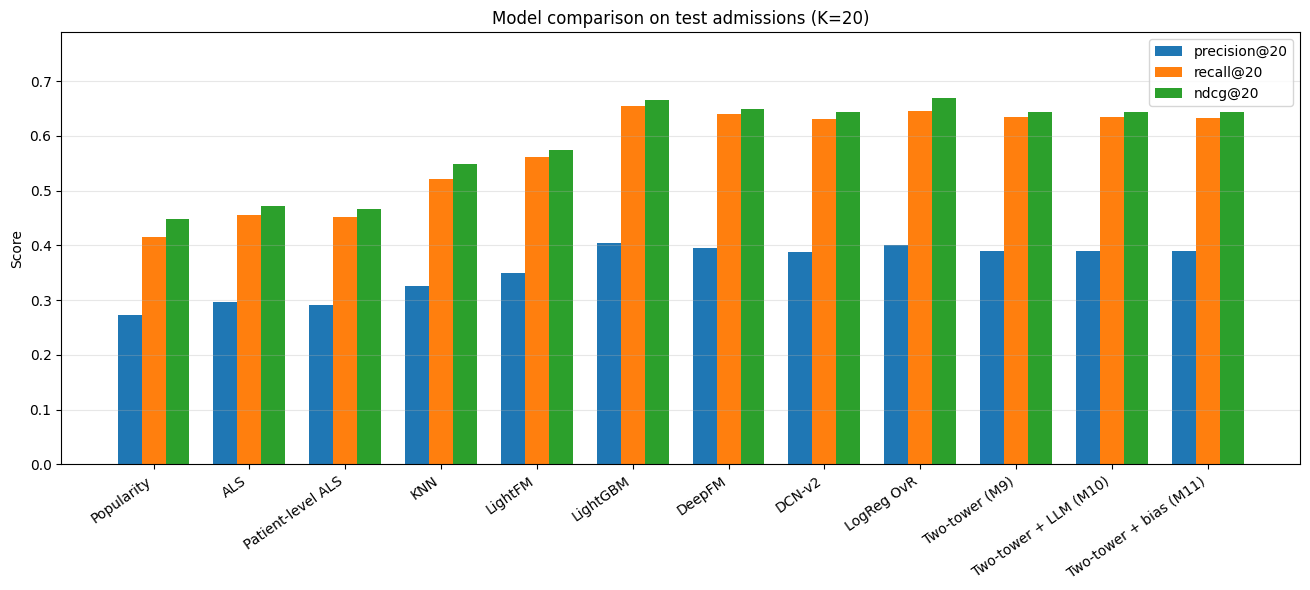


Ranked by ndcg@20:
                 model  precision@20  recall@20  ndcg@20
            LogReg OvR        0.4000     0.6454   0.6691
              LightGBM        0.4048     0.6542   0.6666
                DeepFM        0.3945     0.6401   0.6490
                DCN-v2        0.3886     0.6309   0.6442
 Two-tower + LLM (M10)        0.3904     0.6343   0.6440
        Two-tower (M9)        0.3904     0.6342   0.6438
Two-tower + bias (M11)        0.3895     0.6327   0.6430
               LightFM        0.3492     0.5618   0.5750
                   KNN        0.3260     0.5208   0.5485
                   ALS        0.2958     0.4563   0.4717
     Patient-level ALS        0.2919     0.4519   0.4660
            Popularity        0.2724     0.4161   0.4476


In [17]:
# ========== MODEL COMPARISON: metrics table + bar plot ==========

# Display order (matches notebook training sequence); edit labels as needed.
MODEL_DISPLAY_ORDER = [
    ("popularity", "Popularity"),
    ("als", "ALS"),
    ("patient_als", "Patient-level ALS"),
    ("knn", "KNN"),
    ("lightfm", "LightFM"),
    ("lgbm", "LightGBM"),
    ("deepfm", "DeepFM"),
    ("dcnv2", "DCN-v2"),
    ("logreg_ovr", "LogReg OvR"),
    ("two_tower", "Two-tower (M9)"),
    ("two_tower_llm", "Two-tower + LLM (M10)"),
    ("two_tower_bias", "Two-tower + bias (M11)"),
]

if not ARTIFACTS_PATH.exists():
    raise FileNotFoundError(
        f"No saved metrics at {ARTIFACTS_PATH}. Run the model training cells first."
    )

with open(ARTIFACTS_PATH, "rb") as f:
    _arts = pickle.load(f)

_metrics = _arts.get("metrics", {})
if not _metrics:
    raise ValueError(f"{ARTIFACTS_PATH} has no 'metrics' entries.")

_p_col = f"precision@{K}"
_r_col = f"recall@{K}"
_n_col = f"ndcg@{K}"

_rows = []
_seen = set()
for key, label in MODEL_DISPLAY_ORDER:
    if key not in _metrics:
        continue
    p, r, n = _metrics[key]
    _rows.append({"model": label, "key": key, _p_col: p, _r_col: r, _n_col: n})
    _seen.add(key)

for key in sorted(_metrics.keys()):
    if key in _seen:
        continue
    p, r, n = _metrics[key]
    _rows.append({"model": key, "key": key, _p_col: p, _r_col: r, _n_col: n})

results_df = pd.DataFrame(_rows)
print(f"Test metrics @ K={K} ({len(results_df)} models)\n")
print(results_df.drop(columns=["key"]).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# --- grouped bar chart ---
_metric_cols = [_p_col, _r_col, _n_col]
_plot_df = results_df.set_index("model")[_metric_cols]
_x = np.arange(len(_plot_df))
_bar_w = 0.25

fig, ax = plt.subplots(figsize=(max(10, len(_plot_df) * 1.1), 6))
for i, col in enumerate(_metric_cols):
    ax.bar(_x + (i - 1) * _bar_w, _plot_df[col].values, width=_bar_w, label=col)

ax.set_xticks(_x)
ax.set_xticklabels(_plot_df.index, rotation=35, ha="right")
ax.set_ylim(0, min(1.0, _plot_df.values.max() * 1.15 + 0.02))
ax.set_ylabel("Score")
ax.set_title(f"Model comparison on test admissions (K={K})")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: table sorted by NDCG (best first)
print(f"\nRanked by {_n_col}:")
print(
    results_df.sort_values(_n_col, ascending=False)
    .drop(columns=["key"])
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)
